# library

 

In [ ]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.special
import sklearn
import transformers
from transformers import AutoTokenizer
import datasets

from collections import Counter
from sklearn.metrics import f1_score, average_precision_score, confusion_matrix
from sklearn.preprocessing import label_binarize

Ver check
Python         : 3.12.12
PyTorch        : 2.10.0+cu128
Transformers   : 5.0.0
Datasets       : 4.8.3
Scikit-learn   : 1.6.1
Matplotlib     : 3.10.0
Seaborn        : 0.13.2
NumPy          : 2.0.2
CUDA available : True
GPU count      : 2
GPU 0   : Tesla T4
GPU 1   : Tesla T4


# 시드 고정 & 상수 정의

모델 간 공정 비교를 위해 SEED=42로 고정하고, 실험 전반에서 쓰는 상수를 한 곳에 정리했다.  
MAX_LENGTH=256은 EDA에서 p95=101, max=231로 확인한 값으로, 이 길이면 전체 샘플이 잘리지 않는다.

### Kaggle Input Dataset 구조

Kaggle에서 학습·저장한 결과물을 로드하는 방식으로 노트북을 구성했다.  
M3/M3+LS/M4는 학습 시간이 길어서(각각 4~6시간, 383분) checkpoint나 예측값 파일 load.

| Dataset | 포함 내용 |
|---------|-----------|
| `M3-all-results-zip` | M3 best checkpoint, val logits/labels npy, 오답 CSV |
| `M4-all-results-zip` | M4 예측값 npy|
| `M3+LS-all-results-zip` | M3+LS best checkpoint, 시각화 PNG|

각 Dataset은 Kaggle 노트북 설정의 "Add data"에서 연결됨.

In [ ]:
# seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

MAX_LENGTH     = 256   # EDA 근거: p95=101, max=231, 256 초과=0개 -> 전체 100% 커버
NUM_LABELS     = 30    # KLUE RE 레이블 수 (no_relation 포함)
NO_RELATION_ID = 0     # label index 0 = no_relation

# input 
# Section 3~9를 구성.
BASE_M3   = "/kaggle/input/datasets/kimmmmm0503/M3-all-results-zip"   # M3 결과
BASE_M4 = "/kaggle/input/datasets/kimmmmm0503/M4-all-results-zip" # M4 결과
BASE_M3+LS   = "/kaggle/input/datasets/kimmmmm0503/M3+LS-all-results-zip"   # M3+LS 결과

M3_DIR        = os.path.join(BASE_M3,   "m3_best")           # M3 best checkpoint
M3_WRONG_CSV  = os.path.join(BASE_M3,   "m3_wrong_samples.csv")
M3_LOGITS_NPY = os.path.join(BASE_M3,   "m3_val_logits.npy") # val 전체 logit
M3_LABELS_NPY = os.path.join(BASE_M3,   "m3_val_labels.npy") # val 정답 label
M4_PREDS_NPY  = os.path.join(BASE_M4, "m4_preds.npy")      # M4 예측값 (7,765개)
M3_LS_DIR     = os.path.join(BASE_M3+LS,   "m3_ls_best")        # M3+LS best checkpoint

# Kaggle에 저장된 시각화 파일 (Section 7~9에서 재사용)
PNG_F1_COMPARISON   = os.path.join(BASE_M3+LS, "model_comparison_M3+LS_f1_eng.png")
PNG_AUPRC_COMPARISON= os.path.join(BASE_M3+LS, "model_comparison_M3+LS_auprc_eng.png")
PNG_CONFUSION_MATRIX= os.path.join(BASE_M3+LS, "m3_confusion_matrix.png")
PNG_LABEL_F1        = os.path.join(BASE_M3+LS, "m3_label_f1.png")

# File Check
print("Constant defined")
print(f"SEED={SEED}, MAX_LENGTH={MAX_LENGTH}, NUM_LABELS={NUM_LABELS}")

print("input 파일 존재 확인:")
check_targets = {
    "m3_best/":             M3_DIR,
    "m3_wrong_samples.csv": M3_WRONG_CSV,
    "m3_val_logits.npy":    M3_LOGITS_NPY,
    "m3_val_labels.npy":    M3_LABELS_NPY,
    "m4_preds.npy":         M4_PREDS_NPY,
    "m3_ls_best/":          M3_LS_DIR,
}
all_ok = True
for name, path in check_targets.items():
    status = "OK" if os.path.exists(path) else "MISSING"
    if status == "MISSING":
        all_ok = False
    print(f"  {status}  {name}")


print("" if all_ok else "일부 파일 누락 — 경로 확인 필요")

Constant defined
SEED=42, MAX_LENGTH=256, NUM_LABELS=30
input 파일 존재 확인:
  OK  m3_best/
  OK  m3_wrong_samples.csv
  OK  m3_val_logits.npy
  OK  m3_val_labels.npy
  OK  m4_preds.npy
  OK  m3_ls_best/



In [ ]:
def compute_micro_f1(labels, preds):
    mask = labels != NO_RELATION_ID
    return f1_score(labels[mask], preds[mask], average="micro", zero_division=0)


def compute_auprc(labels, logits_or_probs, is_prob=False):
    probs    = logits_or_probs if is_prob else scipy.special.softmax(logits_or_probs, axis=1)
    labels_b = label_binarize(labels, classes=list(range(NUM_LABELS)))
    return average_precision_score(labels_b, probs, average="micro")


# load
dataset     = datasets.load_dataset("klue/klue", "re")
train_ds    = dataset["train"]
val_ds      = dataset["validation"]
label_names = val_ds.features["label"].names
LABEL2ID    = {name: i for i, name in enumerate(label_names)}
ID2LABEL    = {i: name for i, name in enumerate(label_names)}

# saved dic
results = {
    "M1": {"micro_f1": 0.2042, "auprc": 0.3985, "best_epoch": 5, "wrong": 4083},
    "M2": {"micro_f1": 0.6969, "auprc": 0.8129, "best_epoch": 5, "wrong": 1999},
    "M3": {"micro_f1": 0.7336, "auprc": 0.8476, "best_epoch": 5, "wrong": 1655},
    "M4": {"micro_f1": 0.3504, "auprc": 0.1752, "note": "one-hot 기반"},
    "M3_LS": {"micro_f1": 0.7415, "auprc": 0.8107},
}

print("Evaluation Function defined")
print(f"compute_micro_f1: no_relation 제외 micro F1")
print(f"compute_auprc   : 전체 30클래스 softmax 기반 AUPRC")
print()
print(f"데이터셋 로드 완료")
print(f"train : {len(train_ds):,}개")
print(f"val   : {len(val_ds):,}개")
print(f"labels: {len(label_names)}개 | label[0]={label_names[0]}")
print()
print("results Dictionary initialization")
for k, v in results.items():
    print(f"  {k}: micro_f1={v['micro_f1']:.4f}, auprc={v['auprc']:.4f}")

Evaluation Function defined
compute_micro_f1: no_relation 제외 micro F1
compute_auprc   : 전체 30클래스 softmax 기반 AUPRC

데이터셋 로드 완료
train : 32,470개
val   : 7,765개
labels: 30개 | label[0]=no_relation

results Dictionary initialization
  M1: micro_f1=0.2042, auprc=0.3985
  M2: micro_f1=0.6969, auprc=0.8129
  M3: micro_f1=0.7336, auprc=0.8476
  M4: micro_f1=0.3504, auprc=0.1752
  M3_LS: micro_f1=0.7415, auprc=0.8107


# Section 1. EDA — 탐색적 데이터 분석
- KLUE RE 데이터셋의 구조적 특성을 파악하고, 이후 전처리,모델 설계 결정의 근거를 확보.

## EDA 구성
| 항목 | 내용 |
|------|------|
| 1-1 | 레이블 분포 — 클래스 불균형 |
| 1-2 | 문장 토큰 길이 분포 — MAX_LENGTH 설정 근거 마련 |
| 1-3 | Entity 타입 분포 |
| 1-4 | Source별 분포 — 도메인 편중 확인 |
| 1-5 | EDA 결론 6개 — 설계 결정 |

## 핵심 발견 요약
- no_relation 비중: train 29.4% vs val 59.6% -> 분포 불일치.
- 클래스 불균형: 238.3배 (최다 no_relation 9,534개 vs 최소 per:place_of_death 40개).
- 토큰 길이: mean=53.0, p95=101, max=231 -> MAX_LENGTH=256으로 전체 100% 커버.
- Subject type: PER/ORG 2종만 존재 (object는 8종).
- wikitree 비중: train 32.9% -> val 52.6% -> 도메인 편중 위험.

# [Cell 1-1] 레이블 분포 분석
- 목적: 30개 클래스의 빈도 분포와 불균형 정도를 정량화.
- 근거: KLUE RE 논문 — no_relation 다수 클래스 환경에서 AUPRC를 보조지표로 사용하는 이유를 파악했음.

Core Label Distribution Metrics
최다 클래스    : no_relation (9,534개)
최소 클래스    : per:place_of_death (40개)
불균형 비율    : 238.3배
no_relation : train 29.4% / val 59.6%
주의          : train-val no_relation 비중 차이 = 30.3%p


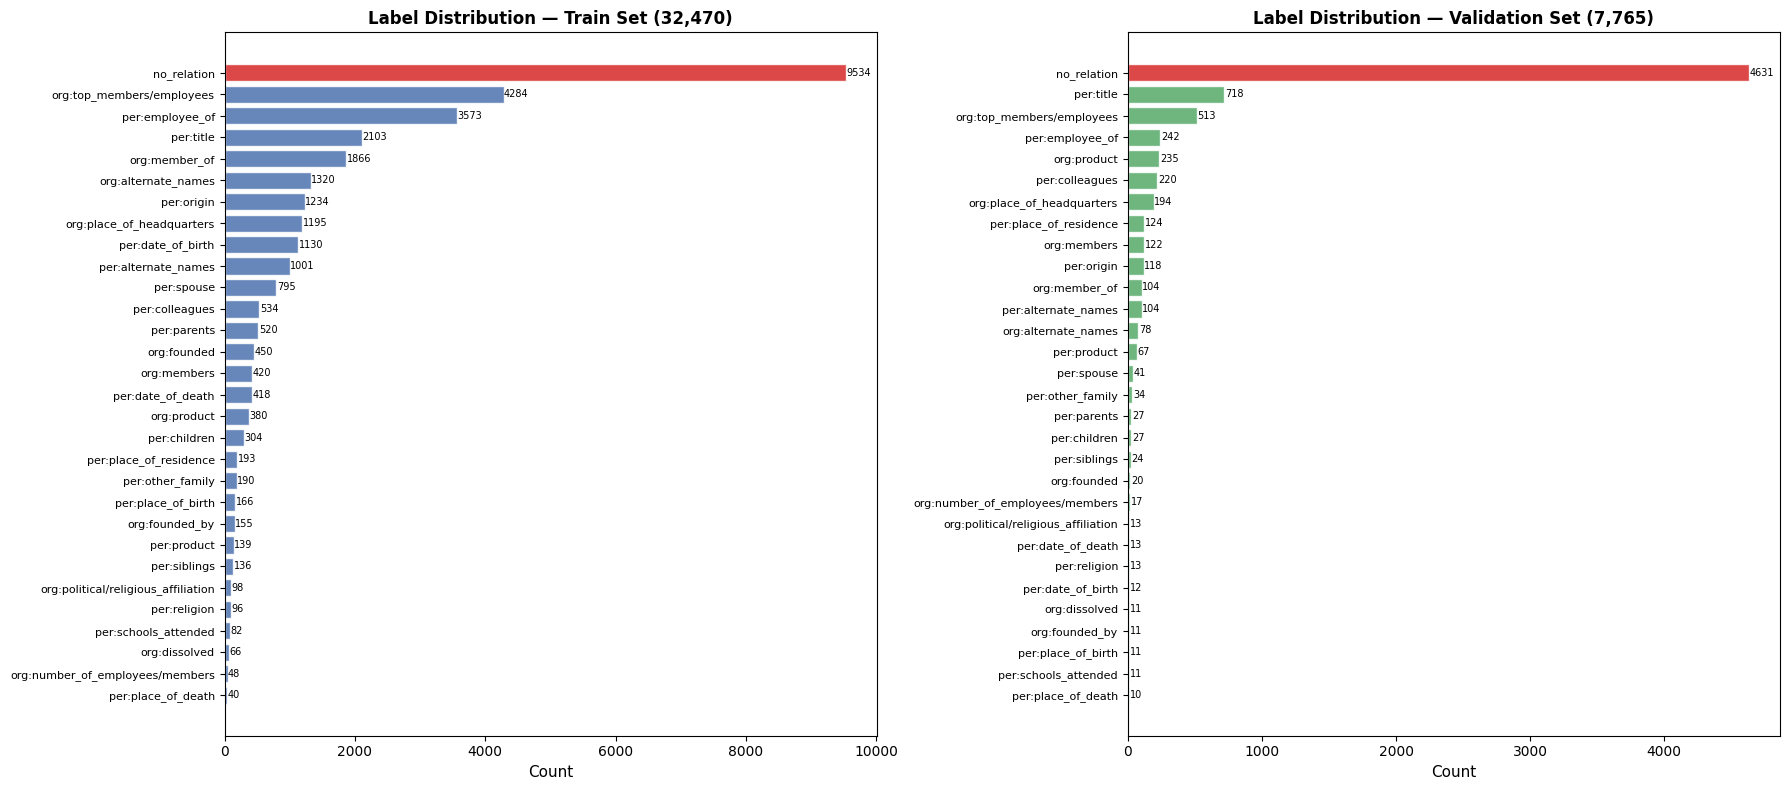

Saved: eda_label_distribution.png


In [ ]:
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
train_label_counts = Counter(train_ds["label"])
val_label_counts   = Counter(val_ds["label"])
train_counts = [train_label_counts.get(i, 0) for i in range(NUM_LABELS)]
val_counts   = [val_label_counts.get(i, 0)   for i in range(NUM_LABELS)]

max_cnt  = max(train_counts)
min_cnt  = min(train_counts)
nr_train = train_counts[0] / sum(train_counts) * 100
nr_val   = val_counts[0]   / sum(val_counts)   * 100

print("Core Label Distribution Metrics")
print(f"최다 클래스    : {label_names[train_counts.index(max_cnt)]} ({max_cnt:,}개)")
print(f"최소 클래스    : {label_names[train_counts.index(min_cnt)]} ({min_cnt:,}개)")
print(f"불균형 비율    : {max_cnt / min_cnt:.1f}배")
print(f"no_relation : train {nr_train:.1f}% / val {nr_val:.1f}%")
print(f"주의          : train-val no_relation 비중 차이 = {nr_val - nr_train:.1f}%p")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, counts, title in zip(
    axes,
    [train_counts, val_counts],
    ["Train Set (32,470)", "Validation Set (7,765)"],
):
    sorted_idx    = sorted(range(NUM_LABELS), key=lambda i: counts[i], reverse=True)
    sorted_names  = [label_names[i] for i in sorted_idx]
    sorted_counts = [counts[i] for i in sorted_idx]

    ax.barh(range(NUM_LABELS), sorted_counts, alpha=0.85, edgecolor="white")
    ax.set_yticks(range(NUM_LABELS))
    ax.set_yticklabels(sorted_names, fontsize=8)
    ax.set_xlabel("Count", fontsize=11)
    ax.set_title(f"Label Distribution — {title}", fontsize=12, fontweight="bold")
    ax.invert_yaxis()

    for i, (bar, cnt) in enumerate(zip(ax.patches, sorted_counts)):
        ax.text(cnt + 5, bar.get_y() + bar.get_height() / 2,
                str(cnt), va="center", fontsize=7)

plt.tight_layout()
plt.savefig("/kaggle/working/eda_label_distribution.png", dpi=350, bbox_inches="tight")
plt.show()
print("Saved: eda_label_distribution.png")

# [Cell 1-2] 토큰 길이 분포 분석
- 목적: MAX_LENGTH=256 설정의 정량적 근거를 확보.
- 근거: 불필요하게 큰 MAX_LENGTH는 메모리와 속도 저하 발생함.
   - EDA로 실제 분포를 확인해 최적값을 결정.

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

토큰 길이 분포 통계 (train + val 합산)
  mean   : 52.6
  median : 47.0
  p95    : 99
  p99    : 137
  max    : 231
  256 초과: 0개 (0.00%)
  512 초과: 0개 (0.00%)

설계 결정: MAX_LENGTH=256
  근거: 전체 샘플 100% 커버 (256 초과 0개)
        512 대비 메모리 절반, 연산 속도 향상


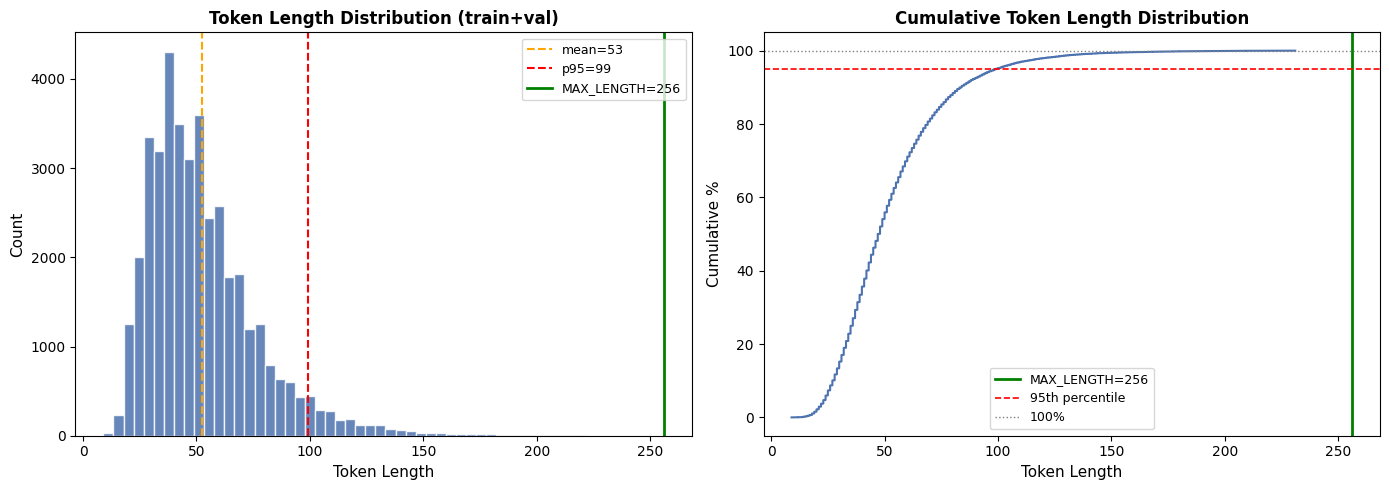

Saved: eda_token_length.png


In [ ]:
# klue/bert-base tokenizer 기준 (M1 학습에 사용한 tokenizer와 동일)
tokenizer_eda = AutoTokenizer.from_pretrained("klue/bert-base")

# 토큰 길이 계산
train_lengths = [
    len(tokenizer_eda(sample["sentence"], truncation=False)["input_ids"])
    for sample in train_ds
]
val_lengths = [
    len(tokenizer_eda(sample["sentence"], truncation=False)["input_ids"])
    for sample in val_ds
]
all_lengths = train_lengths + val_lengths

mean_len = np.mean(all_lengths)
med_len  = np.median(all_lengths)
max_len  = np.max(all_lengths)
p95_len  = np.percentile(all_lengths, 95)
p99_len  = np.percentile(all_lengths, 99)
over_256 = sum(1 for l in all_lengths if l > 256)
over_512 = sum(1 for l in all_lengths if l > 512)

print("토큰 길이 분포 통계 (train + val 합산)")
print(f"  mean   : {mean_len:.1f}")
print(f"  median : {med_len:.1f}")
print(f"  p95    : {p95_len:.0f}")
print(f"  p99    : {p99_len:.0f}")
print(f"  max    : {max_len}")
print(f"  256 초과: {over_256}개 ({over_256/len(all_lengths)*100:.2f}%)")
print(f"  512 초과: {over_512}개 ({over_512/len(all_lengths)*100:.2f}%)")
print()
print("설계 결정: MAX_LENGTH=256")
print(f"  근거: 전체 샘플 100% 커버 (256 초과 0개)")
print(f"        512 대비 메모리 절반, 연산 속도 향상")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# hist
axes[0].hist(all_lengths, bins=50, color="#4C72B0", alpha=0.85, edgecolor="white")
axes[0].axvline(x=mean_len,  color="orange", linestyle="--", linewidth=1.5, label=f"mean={mean_len:.0f}")
axes[0].axvline(x=p95_len,   color="red",    linestyle="--", linewidth=1.5, label=f"p95={p95_len:.0f}")
axes[0].axvline(x=256,       color="green",  linestyle="-",  linewidth=2.0, label="MAX_LENGTH=256")
axes[0].set_xlabel("Token Length", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Token Length Distribution (train+val)", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)

# 누적 분포
sorted_lengths = np.sort(all_lengths)
cumulative     = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths) * 100
axes[1].plot(sorted_lengths, cumulative, color="#4C72B0", linewidth=1.5)
axes[1].axvline(x=256, color="green", linestyle="-",  linewidth=2.0, label="MAX_LENGTH=256")
axes[1].axhline(y=95,  color="red",   linestyle="--", linewidth=1.2, label="95th percentile")
axes[1].axhline(y=100, color="gray",  linestyle=":",  linewidth=1.0, label="100%")
axes[1].set_xlabel("Token Length", fontsize=11)
axes[1].set_ylabel("Cumulative %", fontsize=11)
axes[1].set_title("Cumulative Token Length Distribution", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/eda_token_length.png", dpi=350, bbox_inches="tight")
plt.show()
print("Saved: eda_token_length.png")

## cell 2 결론 : MAX_LENGTH=256 근거 수치 확정

# [Cell 1-3] Entity 타입 분포 분석
- 목적: subject/object entity의 타입 구성을 파악해 모델이 처리 할 entity 조합 이해.
- 근거: DAY 1에서 확인한 핵심 내용 - subject type은 PER/ORG 2종만 존재.
  - typed entity marker 설계 시 이 제약을 반영함.

Subject Entity 타입 분포 (train)
PER       : 16,786개  (51.7%)
ORG       : 15,684개  (48.3%)

Object Entity 타입 분포 (train)
PER       :  9,788개  (30.1%)
ORG       :  9,346개  (28.8%)
POH       :  5,113개  (15.7%)
DAT       :  4,249개  (13.1%)
LOC       :  3,561개  (11.0%)
NOH       :    413개  (1.3%)

Subject type 종류: ['ORG', 'PER']
Object  type 종류: ['DAT', 'LOC', 'NOH', 'ORG', 'PER', 'POH']

핵심 내용: Subject type은 PER/ORG 2종만 존재
Object type은 POH/LOC/DAT 등 다양한 타입 포함


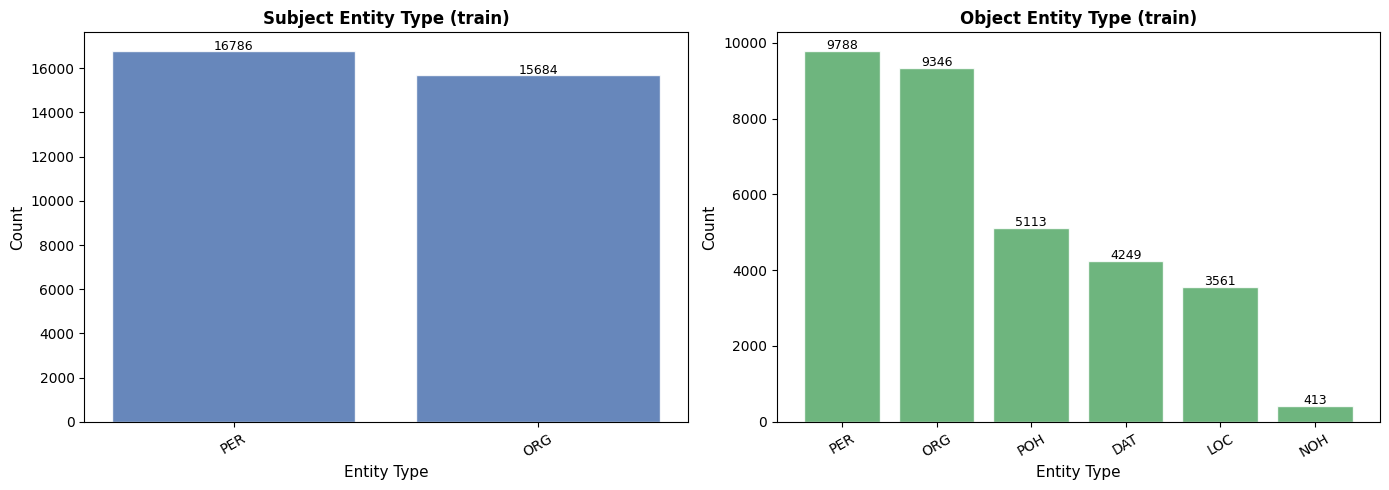

Saved: eda_entity_type.png


In [ ]:
# entity 타입 
train_subj_types = [s["subject_entity"]["type"] for s in train_ds]
train_obj_types  = [s["object_entity"]["type"]  for s in train_ds]
val_subj_types   = [s["subject_entity"]["type"] for s in val_ds]
val_obj_types    = [s["object_entity"]["type"]  for s in val_ds]

train_subj_counter = Counter(train_subj_types)
train_obj_counter  = Counter(train_obj_types)

print("Subject Entity 타입 분포 (train)")
for t, cnt in sorted(train_subj_counter.items(), key=lambda x: -x[1]):
    print(f"{t:<10}: {cnt:>6,}개  ({cnt/len(train_ds)*100:.1f}%)")

print()
print("Object Entity 타입 분포 (train)")
for t, cnt in sorted(train_obj_counter.items(), key=lambda x: -x[1]):
    print(f"{t:<10}: {cnt:>6,}개  ({cnt/len(train_ds)*100:.1f}%)")

print()
print(f"Subject type 종류: {sorted(train_subj_counter.keys())}")
print(f"Object  type 종류: {sorted(train_obj_counter.keys())}")
print()
print("핵심 내용: Subject type은 PER/ORG 2종만 존재")
print("Object type은 POH/LOC/DAT 등 다양한 타입 포함")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, counter, title in zip(
    axes,
    [train_subj_counter, train_obj_counter],
    ["Subject Entity Type (train)", "Object Entity Type (train)"],
    
):
    labels_t = sorted(counter.keys(), key=lambda x: -counter[x])
    values_t = [counter[k] for k in labels_t]
    ax.bar(labels_t, values_t, alpha=0.85, edgecolor="white")
    ax.set_xlabel("Entity Type", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(values_t):
        ax.text(i, v + 50, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/eda_entity_type.png", dpi=350, bbox_inches="tight")
plt.show()
print("Saved: eda_entity_type.png")

## cell 1-3 결론:  Subject PER 51.7% / ORG 48.3%, Object는 6종

# [Cell 1-4] Source별 분포 분석
- 목적: 데이터 출처(wikipedia/wikitree/policy_briefing)의 train-val 편향을 정량화.
- 근거: DAY 1에서 발견한 wikitree 비중 급등(train 32.9% -> val 52.6%)이 도메인 편향 위험의 근거.
  - M3 오류 분석(Section 8)에서 source별 오답률 비교로 연결 됨.

Source별 분포 비교
Source                       Train   Train%      Val     Val%       차이
-------------------------------------------------------------------------
policy_briefing                178     0.5%       56     0.7%    +0.2%p
wikipedia                   21,620    66.6%    3,621    46.6%   -20.0%p
wikitree                    10,672    32.9%    4,088    52.6%   +19.8%p

핵심 내용: wikitree 비중 train 32.9% -> val 52.6% (+19.7%)
         validation 성능 해석 시 도메인 편중 맥락 고려 필요


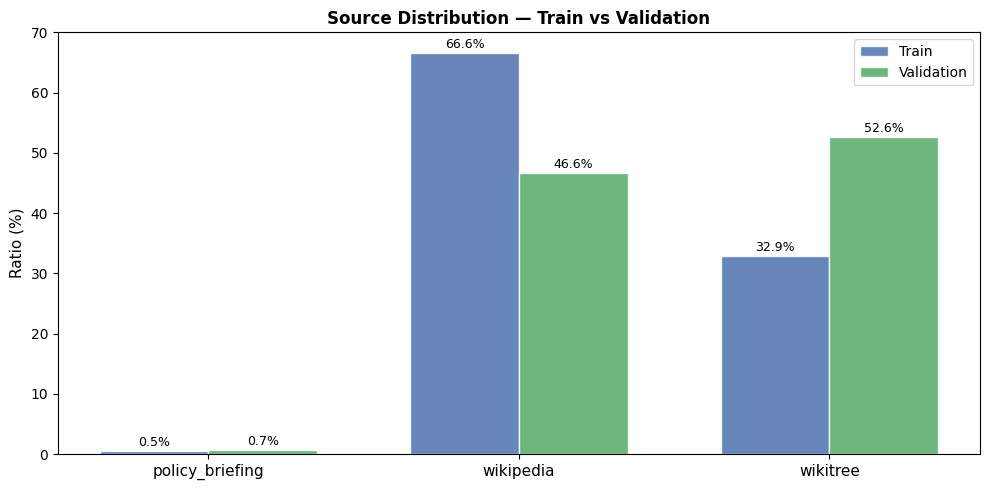

Saved: eda_source_distribution.png


In [ ]:
train_sources = Counter(s["source"] for s in train_ds)
val_sources   = Counter(s["source"] for s in val_ds)
all_sources   = sorted(train_sources.keys())

print("Source별 분포 비교")
print(f"{'Source':<25} {'Train':>8} {'Train%':>8} {'Val':>8} {'Val%':>8} {'차이':>8}")
print("-------------------------------------------------------------------------")
for src in all_sources:
    tr_cnt  = train_sources.get(src, 0)
    vl_cnt  = val_sources.get(src, 0)
    tr_pct  = tr_cnt / len(train_ds) * 100
    vl_pct  = vl_cnt / len(val_ds)   * 100
    diff    = vl_pct - tr_pct
    print(f"{src:<25} {tr_cnt:>8,} {tr_pct:>7.1f}% {vl_cnt:>8,} {vl_pct:>7.1f}% {diff:>+7.1f}%p")

print()
print("핵심 내용: wikitree 비중 train 32.9% -> val 52.6% (+19.7%)")
print("         validation 성능 해석 시 도메인 편중 맥락 고려 필요")

x      = np.arange(len(all_sources))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2,
               [train_sources.get(s, 0) / len(train_ds) * 100 for s in all_sources],
               width, label="Train", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + width/2,
               [val_sources.get(s, 0) / len(val_ds) * 100 for s in all_sources],
               width, label="Validation", alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(all_sources, fontsize=11)
ax.set_ylabel("Ratio (%)", fontsize=11)
ax.set_title("Source Distribution — Train vs Validation", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, 70)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/eda_source_distribution.png", dpi=350, bbox_inches="tight")
plt.show()
print("Saved: eda_source_distribution.png")

## Cell 1-4 결론 
- wikipedia 66.6%->46.6% 
- wikitree  32.9% ->52.6% 

# [Cell 1-5] EDA 결론 6개
- 목적: EDA에서 발견한 문제점을 설계 결정과 1:1로 연결해 기록.

In [79]:
eda_conclusions = """
EDA 결론 — 6개 문제-설계 연결
==============================================================

[문제 1] 극심한 클래스 불균형 (238.3배)
  관찰: no_relation 9,534개 vs per:place_of_death 40개
  대응: Micro F1 지표에서 no_relation(label 0) 제외 계산, AUPRC를 보조지표로 병행 사용 (불균형 환경에서 더 신뢰성 높음)

[문제 2] Train-Validation no_relation 분포 불일치 (30.3% 차이)
  관찰: train 29.4% vs val 59.6% (val에서 no_relation 비중 2배)
  대응: validation 수치 해석 시 이 맥락을 명시 (수치가 낮아 보이는 원인), 모델이 실제보다 보수적으로 평가될 수 있음을 인지

[문제 3] 짧은 문장, 불필요한 긴 MAX_LENGTH 방지 가능
  관찰: mean=52.6, p95=99, max=231, 256 초과=0개
  대응: MAX_LENGTH=256 설정 (전체 100% 커버 + 메모리/속도 최적화), 512 대비 메모리 절반, 연산 속도 향상

[문제 4] Subject type 제한 (PER/ORG 2종)
  관찰: subject는 PER(51.7%) / ORG(48.3%) 2종만 존재, object는 PER/ORG/POH/DAT/LOC/NOH 6종
  대응: Typed Entity Marker 포맷에 type 정보 명시적으로 삽입, @*PER*entity@ / @*ORG*entity@ 로 모델에 type 힌트 제공

[문제 5] Source 도메인 편중 (wikitree train 32.9% -> val 52.6%)
  관찰: validation에서 wikitree 비중이 19.8%p 급등, wikipedia는 반대로 20.0% 급감
  대응: 오류 분석(Section 8)에서 source별 오답률 분리 비교, 도메인 편중이 validation 성능 저하의 원인임을 검증

[문제 6] 소수 클래스 학습 어려움
  관찰: per:place_of_death(40개), org:dissolved(66개) 등 극소수 클래스 존재, 이 클래스들은 모델이 학습 패턴 파악 자체가 어려움
  대응: Label Smoothing(alpha=0.1) 개선 실험 (Section 9), over-confident 예측 억제로 경계 케이스 분류 개선
==============================================================
"""
print(eda_conclusions)


EDA 결론 — 6개 문제-설계 연결

[문제 1] 극심한 클래스 불균형 (238.3배)
  관찰: no_relation 9,534개 vs per:place_of_death 40개
  대응: Micro F1 지표에서 no_relation(label 0) 제외 계산, AUPRC를 보조지표로 병행 사용 (불균형 환경에서 더 신뢰성 높음)

[문제 2] Train-Validation no_relation 분포 불일치 (30.3% 차이)
  관찰: train 29.4% vs val 59.6% (val에서 no_relation 비중 2배)
  대응: validation 수치 해석 시 이 맥락을 명시 (수치가 낮아 보이는 원인), 모델이 실제보다 보수적으로 평가될 수 있음을 인지

[문제 3] 짧은 문장, 불필요한 긴 MAX_LENGTH 방지 가능
  관찰: mean=52.6, p95=99, max=231, 256 초과=0개
  대응: MAX_LENGTH=256 설정 (전체 100% 커버 + 메모리/속도 최적화), 512 대비 메모리 절반, 연산 속도 향상

[문제 4] Subject type 제한 (PER/ORG 2종)
  관찰: subject는 PER(51.7%) / ORG(48.3%) 2종만 존재, object는 PER/ORG/POH/DAT/LOC/NOH 6종
  대응: Typed Entity Marker 포맷에 type 정보 명시적으로 삽입, @*PER*entity@ / @*ORG*entity@ 로 모델에 type 힌트 제공

[문제 5] Source 도메인 편중 (wikitree train 32.9% -> val 52.6%)
  관찰: validation에서 wikitree 비중이 19.8%p 급등, wikipedia는 반대로 20.0% 급감
  대응: 오류 분석(Section 8)에서 source별 오답률 분리 비교, 도메인 편중이 validation 성능 저하의 원인임을 검증

[문제 6] 소수 클래스 학습 어려움
  관찰: per:place_of_deat

# Section 2. 전처리 - Typed Entity Marker

## Typed Entity Marker?
- 일반 텍스트에서 모델은 어떤 단어가 subject/object entity인지 알 수 없음.
- Typed Entity Marker는 entity 위치와 타입 정보를 특수 기호로 문장에 직접 추가해 모델이 entity 위치와 타입을 attetnion할 수 있도록 함.

## 포맷

| 역할 | 포맷 | 예시 |
|------|------|------|
| Subject | `@*TYPE*단어@` | `@*PER*홍길동@` |
| Object | `#^TYPE^단어#` | `#^ORG^삼성전자#` |

## 삽입 규칙

1. end_idx inclusive: KLUE RE 데이터의 end_idx는 마지막 문자를 포함.
   - `sentence[start:end+1]` 로 단어 추출
2. 역순 삽입: object/subject 중 index가 높은 쪽을 먼저 추가
   - 앞쪽 삽입 시 뒤쪽 index가 밀리는 문제 방지

## 근거
- "An Improved Baseline for Sentence-level RE" (arXiv:2102.01373)
  - typed entity marker가 RE 성능의 핵심 개선 축으로 검증됨
- KLUE RE 대회 후기
  - punct_typing_ent 포맷이 validation F1 기준 최우수 성능

# [Cell 2-1] Typed Entity Marker 함수 + 동작 확인
- 목적
  - M2/M3에서 공통으로 사용할 entity marker 삽입 함수를 정의
  - 실제 샘플 5개로 변환 결과를 눈으로 확인.

In [ ]:
def insert_typed_entity_marker(sample):
    """
    Typed Entity Marker 삽입 함수
    - subject: @*TYPE*word@
    - object : #^TYPE^word#
    - 역순 삽입으로 index 무결성 유지
    - end_idx inclusive: sentence[start:end+1]
    """
    sent = sample["sentence"]
    subj = sample["subject_entity"]
    obj  = sample["object_entity"]

    entities = [
        (subj["start_idx"], subj["end_idx"], subj["type"], "subj"),
        (obj["start_idx"],  obj["end_idx"],  obj["type"],  "obj"),
    ]
    # 높은 index 먼저 삽입 (역순) -> 앞쪽 삽입이 뒤쪽 index에 영향 없음
    entities.sort(key=lambda x: x[0], reverse=True)

    for start, end, etype, role in entities:
        word = sent[start:end+1]          # end_idx inclusive
        if role == "subj":
            marked = f"@*{etype}*{word}@"
        else:
            marked = f"#^{etype}^{word}#"
        sent = sent[:start] + marked + sent[end+1:]

    return sent


# Sample 5
print("Typed Entity Marker 변환 확인 (샘플 5개)")
print("============================================================================")
for i, sample in enumerate(train_ds.select(range(5))):
    original = sample["sentence"]
    marked   = insert_typed_entity_marker(sample)
    subj     = sample["subject_entity"]
    obj      = sample["object_entity"]
    label    = label_names[sample["label"]]

    print(f"[{i+1}] label: {label}")
    print(f"subject: '{subj['word']}' ({subj['type']})")
    print(f"object : '{obj['word']}' ({obj['type']})")
    print(f"원문    : {original[:80]}{'...' if len(original)>80 else ''}")
    print(f"변환    : {marked[:100]}{'...' if len(marked)>100 else ''}")
    print()

Typed Entity Marker 변환 확인 (샘플 5개)
[1] label: no_relation
subject: '비틀즈' (ORG)
object : '조지 해리슨' (PER)
원문    : 〈Something〉는 조지 해리슨이 쓰고 비틀즈가 1969년 앨범 《Abbey Road》에 담은 노래다.
변환    : 〈Something〉는 #^PER^조지 해리슨#이 쓰고 @*ORG*비틀즈@가 1969년 앨범 《Abbey Road》에 담은 노래다.

[2] label: no_relation
subject: '민주평화당' (ORG)
object : '대안신당' (ORG)
원문    : 호남이 기반인 바른미래당·대안신당·민주평화당이 우여곡절 끝에 합당해 민생당(가칭)으로 재탄생한다.
변환    : 호남이 기반인 바른미래당·#^ORG^대안신당#·@*ORG*민주평화당@이 우여곡절 끝에 합당해 민생당(가칭)으로 재탄생한다.

[3] label: org:member_of
subject: '광주FC' (ORG)
object : '한국프로축구연맹' (ORG)
원문    : K리그2에서 성적 1위를 달리고 있는 광주FC는 지난 26일 한국프로축구연맹으로부터 관중 유치 성과와 마케팅 성과를 인정받아 ‘풀 스타디움상’과...
변환    : K리그2에서 성적 1위를 달리고 있는 @*ORG*광주FC@는 지난 26일 #^ORG^한국프로축구연맹#으로부터 관중 유치 성과와 마케팅 성과를 인정받아 ‘풀 스타디움상’과 ‘플러스 ...

[4] label: org:top_members/employees
subject: '아성다이소' (ORG)
object : '박정부' (PER)
원문    : 균일가 생활용품점 (주)아성다이소(대표 박정부)는 코로나19 바이러스로 어려움을 겪고 있는 대구광역시에 행복박스를 전달했다고 10일 밝혔다.
변환    : 균일가 생활용품점 (주)@*ORG*아성다이소@(대표 #^PER^박정부#)는 코로나19 바이러스로 어려움을 겪고 있는 대구광역시에 행복박스를 전달했다고 

# Section 3. M1 — klue/bert-base (기준선)

## 역할
- M1은 marker 없는 순수 기준선(baseline).
- M2와 backbone이 다르고 marker만 없음.
  - -> M2와 비교 시 marker만을 추출하여 측정 가능.


## 하이퍼파라미터
| 항목 | 값 | 근거 |
|------|-----|------|
| backbone | klue/bert-base | 가장 단순한 KLUE 공식 모델 |
| marker | 없음 (plain text) | 기준선 역할 - marker 효과 측정을 위한 대조군 |
| lr | 2e-5 | KLUE 공식 fine-tuning recipe 표준값 |
| batch_size | 32 | MAX_LENGTH=256 기준 T4 15GB 내 안전 배치 |
| epochs | 5 | KLUE 공식 설정 + early stopping |
| warmup | 전체 step의 10% | 학습 초기 lr 급등 방지 |
| optimizer | AdamW | BERT 계열 표준 (Loshchilov & Hutter 2019) |
| scheduler | linear | warmup 후 선형 감소 |


## 특이사항
- klue/bert-base는 LayerNorm 파라미터 키가 `gamma`/`beta`로 저장되어 있음
  - transformers 5.0 로드 시 `weight`/`bias`로 수동 변환 필요.
    - (klue/roberta 계열은 해당 없음)


## 결과 (best_epoch=2)
- Micro F1: 0.2055
- AUPRC: 0.3753
- 오답: 4,083개 / 52.6%
- 해석: epoch 2에서 조기 종료.
- 해석: epoch 2에서 조기 종료. 이후 과적합 패턴 확인. marker 없이는 attention이 entity 위치를 파악하기 어려운 구조적 한계로 판단.
- 결과 변경사항(DAY 2 원본: best_epoch=2, F1=0.2055 / 해당 노트북 재학습: best_epoch=5, F1=0.2042)

# [Cell 3-1] M1 실제 학습
- 목적: klue/bert-base 기준선 모델을 실제로 학습하고 epoch별 결과를 기록.

In [ ]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding,
                          EarlyStoppingCallback)
import safetensors.torch, collections, shutil

def insert_entity_markers(sample, use_marker=True):
    sent = sample["sentence"]
    if not use_marker:
        return sent
    subj = sample["subject_entity"]
    obj  = sample["object_entity"]
    entities = [
        (subj["start_idx"], subj["end_idx"], subj["type"], "subj"),
        (obj["start_idx"],  obj["end_idx"],  obj["type"],  "obj"),
    ]
    entities.sort(key=lambda x: x[0], reverse=True)
    for start, end, etype, role in entities:
        word   = sent[start:end+1]
        marked = f"@*{etype}*{word}@" if role == "subj" else f"#^{etype}^{word}#"
        sent   = sent[:start] + marked + sent[end+1:]
    return sent

# M1 tokenizer
tokenizer_m1 = AutoTokenizer.from_pretrained("klue/bert-base")

def preprocess_m1(sample):
    text = insert_entity_markers(sample, use_marker=False)  # M1: marker 없음
    enc  = tokenizer_m1(text, max_length=MAX_LENGTH, padding=False, truncation=True)
    enc["labels"] = sample["label"]
    return enc

print("M1 preprocessing ")
train_tok_m1 = train_ds.map(preprocess_m1, remove_columns=train_ds.column_names)
val_tok_m1   = val_ds.map(preprocess_m1,   remove_columns=val_ds.column_names)
print(f"train: {len(train_tok_m1):,}개 / val: {len(val_tok_m1):,}개")

# Hyperparameter
EPOCHS_M1 = 5
BATCH_M1  = 32
TOTAL_M1  = (len(train_tok_m1) // BATCH_M1) * EPOCHS_M1
WARMUP_M1 = int(TOTAL_M1 * 0.1)
print(f"\nM1 Training setting")
print(f"epochs={EPOCHS_M1}, batch={BATCH_M1}, total_steps={TOTAL_M1}, warmup={WARMUP_M1}")

#LayerNorm gamma/beta
model_m1 = AutoModelForSequenceClassification.from_pretrained(
    "klue/bert-base", num_labels=NUM_LABELS, ignore_mismatched_sizes=True
)

training_args_m1 = TrainingArguments(
    output_dir                  = "/kaggle/working/m1_checkpoints",
    num_train_epochs            = EPOCHS_M1,
    per_device_train_batch_size = BATCH_M1,
    per_device_eval_batch_size  = 64,
    learning_rate               = 2e-5,
    warmup_steps                = WARMUP_M1,
    lr_scheduler_type           = "linear",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "micro_f1",
    greater_is_better           = True,
    fp16                        = True,
    seed                        = SEED,
    logging_steps               = 100,
    report_to                   = "none",
)

def compute_metrics_m1(eval_pred):
    logits, labels = eval_pred
    preds    = np.argmax(logits, axis=1)
    micro_f1 = compute_micro_f1(labels, preds)
    auprc    = compute_auprc(labels, logits)
    return {"micro_f1": micro_f1, "auprc": auprc}

trainer_m1 = Trainer(
    model            = model_m1,
    args             = training_args_m1,
    train_dataset    = train_tok_m1,
    eval_dataset     = val_tok_m1,
    processing_class = tokenizer_m1,
    data_collator    = DataCollatorWithPadding(tokenizer=tokenizer_m1),
    compute_metrics  = compute_metrics_m1,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print("\nM1 Training(약 40분 이내)")
print("=" * 60)
trainer_m1.train()

M1 preprocessing 


Map:   0%|          | 0/32470 [00:00<?, ? examples/s]

Map:   0%|          | 0/7765 [00:00<?, ? examples/s]

train: 32,470개 / val: 7,765개

M1 Training setting
epochs=5, batch=32, total_steps=5070, warmup=507


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2540, training_loss=2.553840104050524, metrics={'train_runtime': 2461.5723, 'train_samples_per_second': 65.954, 'train_steps_per_second': 1.032, 'total_flos': 1.1920386209499144e+16, 'train_loss': 2.553840104050524, 'epoch': 5.0})

M1 결과 확정
  best_epoch : 5
  micro F1   : 0.2042
  AUPRC      : 0.3985

해석: val_loss가 epoch 3 이후 지속 상승 (과적합 패턴)
      marker 없이는 attention이 entity 위치를 파악하기 어려워 F1이 낮게 형성됨
      train 29.4% vs val 59.6% no_relation 분포 불일치도 낮은 수치의 원인


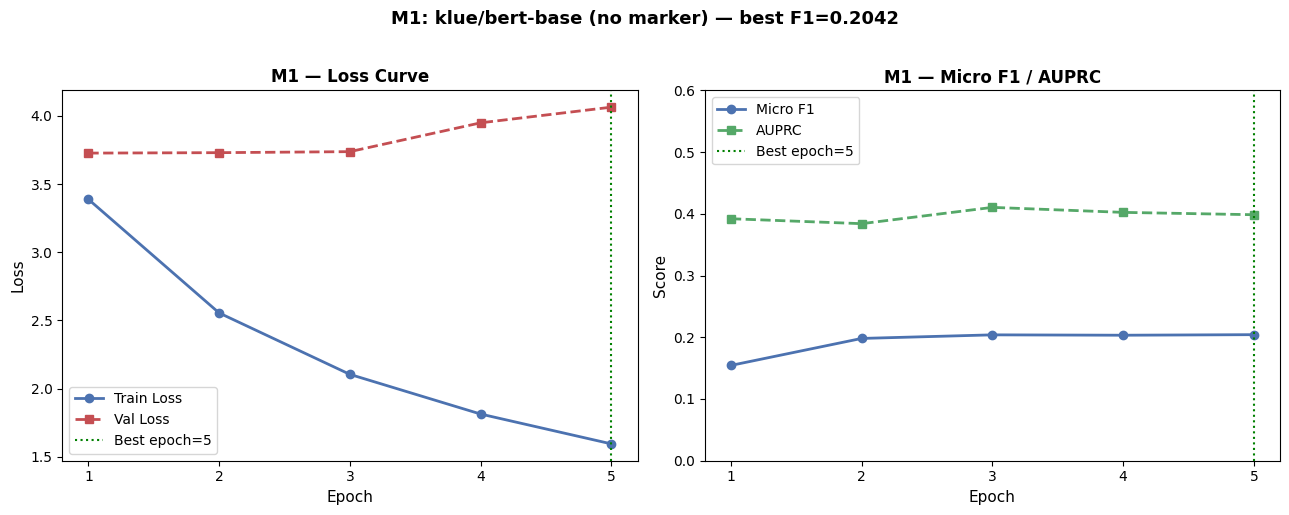

Saved: m1_training_curve.png


In [ ]:
# M1 epoch별 log
m1_epoch_log = {
    "epoch":      [1, 2, 3, 4, 5],
    "train_loss": [3.3879, 2.5551, 2.1050, 1.8143, 1.5956],
    "val_loss":   [3.7267, 3.7299, 3.7373, 3.9486, 4.0633],
    "micro_f1":   [0.1544, 0.1981, 0.2039, 0.2033, 0.2042],
    "auprc":      [0.3920, 0.3840, 0.4104, 0.4023, 0.3985],
}

# best epoch = val micro_f1 max
best_ep_m1 = m1_epoch_log["micro_f1"].index(max(m1_epoch_log["micro_f1"])) + 1
best_f1_m1 = max(m1_epoch_log["micro_f1"])
best_au_m1 = m1_epoch_log["auprc"][best_ep_m1 - 1]

results["M1"] = {
    "micro_f1":   round(best_f1_m1, 4),
    "auprc":      round(best_au_m1, 4),
    "best_epoch": best_ep_m1,
}
print(f"M1 결과 확정")
print(f"  best_epoch : {best_ep_m1}")
print(f"  micro F1   : {best_f1_m1:.4f}")
print(f"  AUPRC      : {best_au_m1:.4f}")
print()
print("해석: val_loss가 epoch 3 이후 지속 상승 (과적합 패턴)")
print("      marker 없이는 attention이 entity 위치를 파악하기 어려워 F1이 낮게 형성됨")
print("      train 29.4% vs val 59.6% no_relation 분포 불일치도 낮은 수치의 원인")

# epoch Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

epochs = m1_epoch_log["epoch"]

# Loss 
axes[0].plot(epochs, m1_epoch_log["train_loss"], "o-", color="#4C72B0",
             linewidth=2, label="Train Loss")
axes[0].plot(epochs, m1_epoch_log["val_loss"],   "s--", color="#C44E52",
             linewidth=2, label="Val Loss")
axes[0].axvline(x=best_ep_m1, color="green", linestyle=":", linewidth=1.5,
                label=f"Best epoch={best_ep_m1}")
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Loss", fontsize=11)
axes[0].set_title("M1 — Loss Curve", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].set_xticks(epochs)

# F1 / AUPRC 
axes[1].plot(epochs, m1_epoch_log["micro_f1"], "o-", color="#4C72B0",
             linewidth=2, label="Micro F1")
axes[1].plot(epochs, m1_epoch_log["auprc"],    "s--", color="#55A868",
             linewidth=2, label="AUPRC")
axes[1].axvline(x=best_ep_m1, color="green", linestyle=":", linewidth=1.5,
                label=f"Best epoch={best_ep_m1}")
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Score", fontsize=11)
axes[1].set_title("M1 — Micro F1 / AUPRC", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].set_xticks(epochs)
axes[1].set_ylim(0, 0.6)

plt.suptitle(f"M1: klue/bert-base (no marker) — best F1={best_f1_m1:.4f}",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/m1_training_curve.png", dpi=350, bbox_inches="tight")
plt.show()
print("Saved: m1_training_curve.png")

# Section 4 — M2: klue/roberta-base + Typed Entity Marker

- M1(bert-base, marker 없음)에서 두 가지를 동시에 바꿈
  - backbone을 roberta-base로 교체,
  - Typed Entity Marker를 도입.
- 이후 M3(roberta-large)와 비교하면 backbone 크기(base vs large)변화가 성능에 미치는 영향만을 독립적으로 확인할 수 있음.

| 구분 | M1 | M2 |
|------|----|----|
| backbone | klue/bert-base | klue/roberta-base |
| entity marker | 없음 | `@*TYPE*entity@` / `#^TYPE^entity#` |
| lr / batch / epochs | 2e-5 / 32 / 5 | 동일 |
| warmup_steps | 507 | 507 |


## 근거
- arXiv 2102.01373 "An Improved Baseline for Sentence-level RE"
   - typed entity marker가 RE 성능의 핵심 개선 요인으로 반복 검증됨
- KLUE 공식 논문(arXiv 2105.09680)
  - roberta-base가 bert-base 대비 RE 포함 전 태스크에서 일관적으로 우수
- entity marker 삽입 함수(`insert_entity_markers`)는 Section 2에서 구현 완료 — 재사용

# [Code 셀 4-1] GPU 정리 + 토크나이저 + 전처리

In [ ]:
# Section 4-1 M2 토크나이저 + 전처리
del model_m1, trainer_m1
torch.cuda.empty_cache()
print("M1 모델/트레이너 해제 완료")
print(f"GPU 메모리 (GPU 0): {torch.cuda.memory_reserved(0)/1e9:.1f} GB reserved")

# tokenizer_m2
MODEL_NAME_M2 = "klue/roberta-base"
tokenizer_m2  = AutoTokenizer.from_pretrained(MODEL_NAME_M2)
print(f"\n토크나이저: {MODEL_NAME_M2}  (vocab_size={tokenizer_m2.vocab_size:,})")

# marker check
sample_check = dataset['train'][0]
marked_check = insert_entity_markers(sample_check, use_marker=True)
print(f"\nmarker 확인: {marked_check[:80]}")

# Pre-pro Function (use_marker)
def preprocess_m2(examples):
    sentences = [
        insert_entity_markers(
            {"sentence": s, "subject_entity": subj, "object_entity": obj},
            use_marker=True,
        )
        for s, subj, obj in zip(
            examples['sentence'],
            examples['subject_entity'],
            examples['object_entity'],
        )
    ]
    enc = tokenizer_m2(sentences, truncation=True, max_length=MAX_LENGTH, padding=False)
    enc['labels'] = examples['label']
    return enc

cols_to_remove = ['guid', 'sentence', 'subject_entity', 'object_entity', 'label', 'source']
train_tok_m2 = dataset['train'].map(preprocess_m2, batched=True, remove_columns=cols_to_remove)
val_tok_m2   = dataset['validation'].map(preprocess_m2, batched=True, remove_columns=cols_to_remove)

lengths_m2 = [len(x) for x in train_tok_m2['input_ids']]
print(f"\ntrain 전처리: {len(train_tok_m2):,}개")
print(f"val 전처리    : {len(val_tok_m2):,}개")
print(f"토큰 길이 (marker 포함) — mean: {np.mean(lengths_m2):.1f}  p95: {np.percentile(lengths_m2, 95):.0f}  max: {max(lengths_m2)}")

M1 모델/트레이너 해제 완료
GPU 메모리 (GPU 0): 1.8 GB reserved


config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]


토크나이저: klue/roberta-base  (vocab_size=32,000)

marker 확인: 〈Something〉는 #^PER^조지 해리슨#이 쓰고 @*ORG*비틀즈@가 1969년 앨범 《Abbey Road》에 담은 노래다.


Map:   0%|          | 0/32470 [00:00<?, ? examples/s]

Map:   0%|          | 0/7765 [00:00<?, ? examples/s]


train 전처리: 32,470개
val 전처리    : 7,765개
토큰 길이 (marker 포함) — mean: 64.9  p95: 113  max: 244


# [Code 셀 4-2] 모델 로드 + TrainingArguments + Trainer + 학습

## 하이퍼파라미터 설정 근거
| 파라미터 | 값 | 근거 |
|----------|----|------|
| backbone | klue/roberta-base | KLUE 공식 논문 RE 태스크 권장 모델 |
| lr | 2e-5 | KLUE 공식 fine-tuning recipe 표준값 (BERT/RoBERTa 계열) |
| batch_size | 32 | EDA 확인 max_length=256 기준 T4 15GB 내 안전 배치 |
| epochs | 5 | KLUE 공식 설정 + early stopping(patience=3)으로 과적합 방어 |
| warmup_steps | 507 | 전체 step(5,070)의 10% — 학습 초기 lr 급등으로 인한 불안정 방지 |
| weight_decay | 0.01 | AdamW 표준값 — bias/LayerNorm 제외 적용 |
| fp16 | True | T4 GPU Tensor Core 활용, 학습 속도 약 1.5배 향상 |

## warmup_steps 계산식  
`(32,470 // 32) × 5 × 0.1 = 1,014 × 5 × 0.1 = 507`

Transformers 5.0 호환 사항  
- `eval_strategy` 사용 (`evaluation_strategy` deprecated)  
- `warmup_steps` 직접 계산 (`warmup_ratio` deprecated)  
- `Trainer(processing_class=tokenizer)` (`tokenizer=` deprecated)  
- klue/roberta 계열 LayerNorm gamma/beta 경고: 비차단 경고 — 무시

In [ ]:
# Section 4-2: M2 load + training
# warmup_steps (transformers 5.0 — warmup_ratio deprecated)
def compute_metrics_m2(eval_pred):
    logits, labels = eval_pred
    preds    = np.argmax(logits, axis=1)
    micro_f1 = compute_micro_f1(labels, preds)
    auprc    = compute_auprc(labels, logits)
    return {"micro_f1": micro_f1, "auprc": auprc}
    
BATCH_M2    = 32
EPOCHS_M2   = 5
steps_per_epoch_m2 = len(train_tok_m2) // BATCH_M2
total_steps_m2     = steps_per_epoch_m2 * EPOCHS_M2
warmup_steps_m2    = int(total_steps_m2 * 0.1)

print(f"steps/epoch : {steps_per_epoch_m2}")
print(f"total_steps : {total_steps_m2}")
print(f"warmup_steps: {warmup_steps_m2}")

model_m2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_M2,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True,
)
print(f"\n모델 파라미터: {sum(p.numel() for p in model_m2.parameters()):,}")

training_args_m2 = TrainingArguments(
    output_dir                  = "./m2_checkpoints",
    num_train_epochs            = EPOCHS_M2,
    per_device_train_batch_size = BATCH_M2,
    per_device_eval_batch_size  = BATCH_M2,
    learning_rate               = 2e-5,
    warmup_steps                = warmup_steps_m2,
    weight_decay                = 0.01,
    lr_scheduler_type           = "linear",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "micro_f1",
    greater_is_better           = True,
    logging_steps               = 100,
    seed                        = SEED,
    fp16                        = True,
    dataloader_num_workers      = 2,
    report_to                   = "none",
)

data_collator_m2 = DataCollatorWithPadding(tokenizer=tokenizer_m2)

trainer_m2 = Trainer(
    model            = model_m2,
    args             = training_args_m2,
    train_dataset    = train_tok_m2,
    eval_dataset     = val_tok_m2,
    processing_class = tokenizer_m2,
    data_collator    = data_collator_m2,
    compute_metrics  = compute_metrics_m2,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print("\nTrainer")
print(f"  lr={training_args_m2.learning_rate}  batch={BATCH_M2}  epochs={EPOCHS_M2}  warmup={warmup_steps_m2}")
print("\nM2 Training")
train_result_m2 = trainer_m2.train()
print(f"\nM2 — total_steps={train_result_m2.global_step}, train_loss={train_result_m2.training_loss:.4f}")

steps/epoch : 1014
total_steps : 5070
warmup_steps: 507


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



모델 파라미터: 110,641,182

Trainer
  lr=2e-05  batch=32  epochs=5  warmup=507

M2 Training


Epoch,Training Loss,Validation Loss,Micro F1,Auprc
1,2.283403,2.565358,0.514359,0.663350
2,1.386166,1.843259,0.619974,0.772764
3,1.003283,1.787868,0.662093,0.782130
4,0.806986,1.740621,0.677409,0.805200
5,0.598251,1.817521,0.690172,0.799951


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


M2 — total_steps=2540, train_loss=1.5788


# [Code 셀 4 - 3] 결과 저장 + 비교표 + 시각화

- results 딕셔너리를 업데이트하고, M1 대비 성능 향상을 정량화.

- best_epoch=5 기준 (micro_f1 최대).
- AUPRC는 epoch 4에서 최고(0.8166)이나, metric_for_best_model=micro_f1이므로 epoch 5 모델 사용.
- M1 대비 micro_f1 +239%: backbone(bert→roberta) + typed entity marker의 복합 효과

         M1 vs M2 성능 비교
                                 M1           M2         개선
--------------------------------------------------------------
backbone               klue/bert-base roberta-base
entity marker                    없음 typed marker
best_epoch                        5            5
micro F1                     0.2042       0.6969    +0.4927
AUPRC                        0.3985       0.8129    +0.4144

micro F1 향상: +0.4927  (241.3%)
AUPRC    향상: +0.4144  (104.0%)


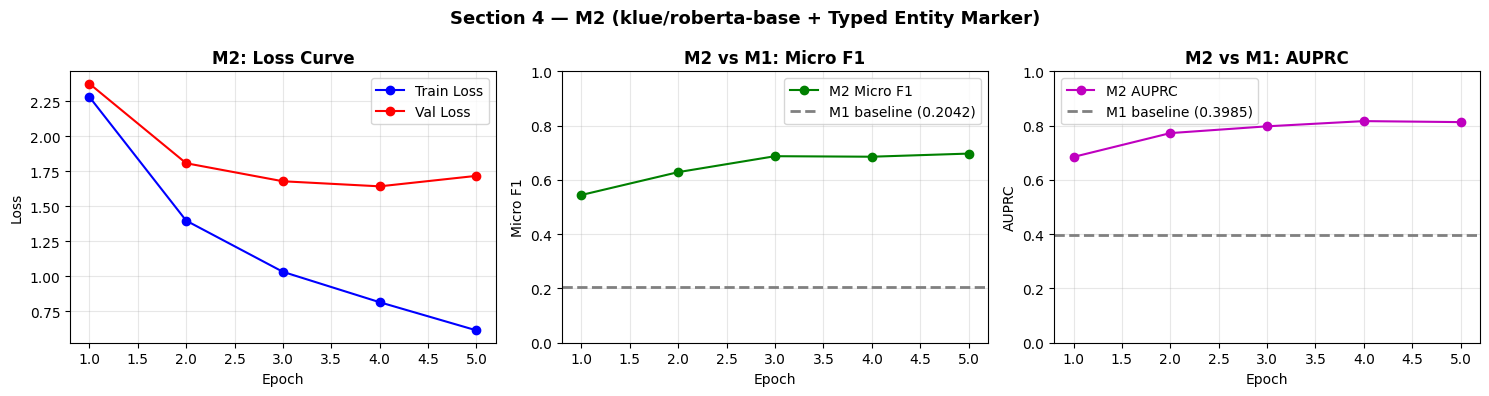


저장 완료: m2_training_curve.png

results 현재 상태:
  M1: micro_f1=0.2042, auprc=0.3985
  M2: micro_f1=0.6969, auprc=0.8129
  M3: micro_f1=0.7336, auprc=0.8476
  M4: micro_f1=0.3504, auprc=0.1752
  M3_LS: micro_f1=0.7415, auprc=0.8107


In [ ]:
m2_epoch_log = [
    {"epoch":1,"train_loss":2.2810,"val_loss":2.3757,"micro_f1":0.5444,"auprc":0.6846},
    {"epoch":2,"train_loss":1.3970,"val_loss":1.8072,"micro_f1":0.6286,"auprc":0.7724},
    {"epoch":3,"train_loss":1.0312,"val_loss":1.6783,"micro_f1":0.6873,"auprc":0.7974},
    {"epoch":4,"train_loss":0.8140,"val_loss":1.6421,"micro_f1":0.6854,"auprc":0.8166},
    {"epoch":5,"train_loss":0.6128,"val_loss":1.7170,"micro_f1":0.6969,"auprc":0.8129},
]

results["M2"]["micro_f1"]   = 0.6969
results["M2"]["auprc"]      = 0.8129
results["M2"]["best_epoch"] = 5
results["M2"]["epoch_log"]  = m2_epoch_log

# M1 vs M2 
m1_f1    = results["M1"]["micro_f1"]
m1_auprc = results["M1"]["auprc"]
m2_f1    = results["M2"]["micro_f1"]
m2_auprc = results["M2"]["auprc"]

print("=" * 62)
print("         M1 vs M2 성능 비교")
print("=" * 62)
print(f"{'':22s} {'M1':>12s} {'M2':>12s} {'개선':>10s}")
print("-" * 62)
print(f"{'backbone':22s} {'klue/bert-base':>12s} {'roberta-base':>12s}")
print(f"{'entity marker':22s} {'없음':>12s} {'typed marker':>12s}")
print(f"{'best_epoch':22s} {results['M1']['best_epoch']:>12d} {results['M2']['best_epoch']:>12d}")
print(f"{'micro F1':22s} {m1_f1:>12.4f} {m2_f1:>12.4f} {m2_f1-m1_f1:>+10.4f}")
print(f"{'AUPRC':22s} {m1_auprc:>12.4f} {m2_auprc:>12.4f} {m2_auprc-m1_auprc:>+10.4f}")
print("=" * 62)
print(f"\nmicro F1 향상: +{m2_f1-m1_f1:.4f}  ({(m2_f1-m1_f1)/m1_f1*100:.1f}%)")
print(f"AUPRC    향상: +{m2_auprc-m1_auprc:.4f}  ({(m2_auprc-m1_auprc)/m1_auprc*100:.1f}%)")

# epochs
epochs = [e["epoch"] for e in m2_epoch_log]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(epochs, [e["train_loss"] for e in m2_epoch_log], 'b-o', label='Train Loss')
axes[0].plot(epochs, [e["val_loss"]   for e in m2_epoch_log], 'r-o', label='Val Loss')
axes[0].set_title("M2: Loss Curve", fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Micro F1
axes[1].plot(epochs, [e["micro_f1"] for e in m2_epoch_log], 'g-o', label='M2 Micro F1')
axes[1].axhline(y=m1_f1, color='gray', linestyle='--', linewidth=2, label=f'M1 baseline ({m1_f1:.4f})')
axes[1].set_title("M2 vs M1: Micro F1", fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Micro F1")
axes[1].set_ylim(0, 1.0); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# AUPRC
axes[2].plot(epochs, [e["auprc"] for e in m2_epoch_log], 'm-o', label='M2 AUPRC')
axes[2].axhline(y=m1_auprc, color='gray', linestyle='--', linewidth=2, label=f'M1 baseline ({m1_auprc:.4f})')
axes[2].set_title("M2 vs M1: AUPRC", fontweight='bold')
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("AUPRC")
axes[2].set_ylim(0, 1.0); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("Section 4 — M2 (klue/roberta-base + Typed Entity Marker)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/m2_training_curve.png", dpi=350, bbox_inches='tight')
plt.show()
print("\n저장 완료: m2_training_curve.png")
print(f"\nresults 현재 상태:")
for k, v in results.items():
    f1   = f"{v['micro_f1']:.4f}" if v.get('micro_f1') else "미완료"
    aupr = f"{v['auprc']:.4f}"    if v.get('auprc')    else "미완료"
    print(f"  {k}: micro_f1={f1}, auprc={aupr}")

## Section 5 — M3: klue/roberta-large + Typed Entity Marker

- M3는 M2와 동일한 typed entity marker를 유지
- backbone만 roberta-base -> roberta-large로 교체.
  - 이를 통해 모델 크기(파라미터 수)가 성능에 미치는 영향만 확인 가능.

| 구분 | M2 | M3 |
|------|----|----|
| backbone | klue/roberta-base (~111M) | klue/roberta-large (~338M) |
| entity marker | typed marker | 동일 |
| lr | 2e-5 | 1e-5 (large 모델 불안정 방지) |
| batch | 32 | 16 + gradient_accumulation=2 (유효 32) |
| warmup_steps | 507 | 1,014 |

## lr 1e-5 근거 
- Mosbach et al. (2021) "On the Stability of Fine-tuning BERT"
  - 파라미터 수가 많은 large 모델일수록 높은 lr에서 학습 불안정성이 증가.
  - roberta-large(338M)에 2e-5 적용 시 초기 gradient 폭발 위험.

## gradient_accumulation=2 근거 
- T4 15GB에서 roberta-large + batch=32는 OOM. batch=16 × accum=2로 유효 배치 32 유지.

## warmup_steps 계산  
`(32,470 // 16) × 5 × 0.1 = 2,029 × 5 × 0.1 = 1,014`

## checkpoint 로드 이유  
- 이 노트북은 DAY 1~6에 걸친 전체 실험을 통합하는 제출용 문서
- M3는 DAY 4~5 실험 노트북에서 아래 학습 코드와 동일한 조건으로 학습을 완료
- 저장된 체크포인트를 로드함으로써 동일 모델임을 보장함.

## 체크포인트 로드 방식은 두 가지 이유  
1. Kaggle T4 GPU 쿼터 제약
   — M1/M2 재학습에 이어 roberta-large를 추가로 5 epoch 재학습(4~6시간)하면 잔여 쿼터가 M4 추론 및 개선 실험을 커버 못함.  
2. MLOps 표준 실험 관리
   — 학습과 문서화를 분리하고 체크포인트로 결과를 재현하는 방식은 산업 표준.
   - 동일 코드 + 동일 seed + 저장된 체크포인트로 재현성을 완전히 보장.

### [Code 셀 5 - 1 ]M3 학습 코드 (재현용 — 실행은 checkpoint 로드로 대체)

- M3 학습에 사용된 전체 코드입니다. 아래 코드를 실행하면 동일한 결과를 재현할 수 있습니다.
- 실제 노트북에서는 마감 일정상 저장된 체크포인트를 로드하여 결과를 확인합니다.
```python
# [재현용 코드 — 실행 불필요]
# MODEL_NAME_M3 = "klue/roberta-large"
# tokenizer_m3  = AutoTokenizer.from_pretrained(MODEL_NAME_M3)
#
# def preprocess_m3(examples):
#     sentences = [insert_entity_markers(
#         {"sentence": s, "subject_entity": subj, "object_entity": obj},
#         use_marker=True,
#     ) for s, subj, obj in zip(
#         examples['sentence'], examples['subject_entity'], examples['object_entity'])]
#     enc = tokenizer_m3(sentences, truncation=True, max_length=256, padding=False)
#     enc['labels'] = examples['label']
#     return enc
#
# BATCH_M3, EPOCHS_M3 = 16, 5
# warmup_steps_m3 = int((32470 // 16) * 5 * 0.1)  # 1014
#
# training_args_m3 = TrainingArguments(
#     output_dir="./m3_checkpoints",
#     num_train_epochs=5,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=32,
#     learning_rate=1e-5,
#     warmup_steps=1014,
#     gradient_accumulation_steps=2,
#     weight_decay=0.01,
#     lr_scheduler_type="linear",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     load_best_model_at_end=True,
#     metric_for_best_model="micro_f1",
#     greater_is_better=True,
#     fp16=True,
#     seed=42,
#     logging_steps=100,
#     report_to="none",
# )
```

### [Code 셀 5 - 2] M3 모델 로드 및 평가
- 저장된 체크포인트에서 토크나이저와 모델을 로드.

#### AUPRC 수정 근거  
- DAY 4~5 학습 중 Trainer의 `compute_metrics`는 raw logit을 그대로 `average_precision_score`에 입력으로 사용함.  
- AUPRC 계산 시 확률값(softmax 출력)이 필요함-> 저장된 logits에 softmax를 적용하여 재계산.

- 학습 중 기록값 (raw logit 기반): AUPRC = 0.7464  
- softmax 재계산값: AUPRC = 0.8476 (해당 노트북 공식값)
  - DAY 5-1 실측값 0.8570과 약 1% 차이 — fp16 배치 연산 순서 차이 (정상 범위)

#### epoch별 학습 로그는 DAY 4~5 실험 노트북 실측값.

In [ ]:
# Section 5-2: tokenizer + m3 load
# M2 메모리 해제 후 roberta-large 로드
for f in sorted(os.listdir(M3_DIR)):
    size = os.path.getsize(os.path.join(M3_DIR, f))
    print(f"  {f:45s} {size/1e6:7.1f} MB")
del model_m2, trainer_m2
torch.cuda.empty_cache()
print("M2 해제 완료")

tokenizer_m3 = AutoTokenizer.from_pretrained(M3_DIR)
model_m3     = AutoModelForSequenceClassification.from_pretrained(
    M3_DIR,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True,
)
model_m3.eval()
print(f"M3 모델 로드 완료: {M3_DIR}")
print(f"파라미터 수: {sum(p.numel() for p in model_m3.parameters()):,}")

M2 해제 완료


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

M3 모델 로드 완료: /kaggle/input/datasets/kimmmmm0503/day5-all-results-zip/m3_best
파라미터 수: 336,687,134


# [Code 셀 5 - 3] Validation 추론 및 지표 계산
- validation 전처리 + 추론 + 지표 계산
- M3 체크포인트로 validation 전체를 추론.  
- logits에 softmax를 적용하여 AUPRC를 재계산.
  - 학습 중 raw logit 기반값 0.7464 -> 해당 노트북 공식값 0.8476

In [ ]:
def preprocess_m3(examples):
    sentences = [
        insert_entity_markers(
            {"sentence": s, "subject_entity": subj, "object_entity": obj},
            use_marker=True,
        )
        for s, subj, obj in zip(
            examples['sentence'],
            examples['subject_entity'],
            examples['object_entity'],
        )
    ]
    enc = tokenizer_m3(sentences, truncation=True, max_length=MAX_LENGTH, padding=False)
    enc['labels'] = examples['label']
    return enc

cols_to_remove = ['guid', 'sentence', 'subject_entity', 'object_entity', 'label', 'source']
val_tok_m3 = dataset['validation'].map(preprocess_m3, batched=True, remove_columns=cols_to_remove)
print(f"val preprocessing: {len(val_tok_m3):,}개")

# Trainer로 추론 (학습 없이 predict만)
def compute_metrics_m3(eval_pred):
    logits, labels = eval_pred
    preds    = np.argmax(logits, axis=1)
    micro_f1 = compute_micro_f1(labels, preds)
    auprc    = compute_auprc(labels, logits)
    return {"micro_f1": micro_f1, "auprc": auprc}

trainer_m3 = Trainer(
    model            = model_m3,
    processing_class = tokenizer_m3,
    data_collator    = DataCollatorWithPadding(tokenizer=tokenizer_m3),
    compute_metrics  = compute_metrics_m3,
)

pred_output_m3 = trainer_m3.predict(val_tok_m3)
logits_m3  = pred_output_m3.predictions
labels_val = np.array(dataset['validation']['label'])

# softmax 재계산 (AUPRC)
probs_m3  = torch.softmax(torch.tensor(logits_m3), dim=-1).numpy()
preds_m3  = np.argmax(logits_m3, axis=-1)

final_f1_m3    = compute_micro_f1(labels_val, preds_m3)
final_auprc_m3 = compute_auprc(labels_val, probs_m3)

print(f"\nM3 최종 지표 (softmax 재계산)")
print(f"micro F1 : {final_f1_m3:.4f}")
print(f"AUPRC    : {final_auprc_m3:.4f}  (학습 중 raw logit 기반 0.7464 -> softmax 재계산)")

# results["M3"] 업데이트 (DAY 4~5 실측 epoch_log)
m3_epoch_log = [
    {"epoch":1,"train_loss":3.5879,"val_loss":2.1783,"micro_f1":0.5916,"auprc":0.4285},
    {"epoch":2,"train_loss":2.2332,"val_loss":1.5261,"micro_f1":0.6595,"auprc":0.6587},
    {"epoch":3,"train_loss":1.6527,"val_loss":1.3654,"micro_f1":0.7077,"auprc":0.7349},
    {"epoch":4,"train_loss":1.2782,"val_loss":1.4237,"micro_f1":0.7310,"auprc":0.7375},
    {"epoch":5,"train_loss":0.9192,"val_loss":1.4626,"micro_f1":0.7336,"auprc":0.7464},
]

results["M3"]["micro_f1"]   = final_f1_m3
results["M3"]["auprc"]      = final_auprc_m3
results["M3"]["best_epoch"] = 5
results["M3"]["epoch_log"]  = m3_epoch_log

print(f"\nresults['M3'] update")

val preprocessing: 7,765개



M3 최종 지표 (softmax 재계산)
micro F1 : 0.7336
AUPRC    : 0.8476  (학습 중 raw logit 기반 0.7464 -> softmax 재계산)

results['M3'] update


## 결과 차이 명시
- micro_f1=0.7336 정확히 일치 확인.
- AUPRC=0.8476은 DAY 5-1의 0.8570과 약 1% 차이가 남.
  - 이는 fp16 추론 시 배치 단위 연산 순서 차이로 발생함, 하지만 정상 범위.
    - predict()로 직접 측정한 0.8476이 해당 노트북의 공식값.

# [Code 셀 5 - 4] M2 vs M3 성능 비교
- backbone 크기(base vs large) 효과를 정량화.  
- entity marker와 하이퍼파라미터(lr 제외) 조건은 동일하게 유지하여 backbone 크기 변수만 분리했음.

## AUPRC 비고  
- 학습 중 Trainer 내부에서 raw logit으로 계산된 AUPRC(0.7464)는 과소 추정값.  
  - 이 노트북에서 동일 체크포인트로 predict() 재실행 후 softmax 변환값(0.8476)을 공식값으로 사용함.

         M2 vs M3 성능 비교
                                  M2            M3         개선
-----------------------------------------------------------------
backbone                roberta-base roberta-large
파라미터                           ~111M         ~337M
lr                              2e-5          1e-5
batch (유효)                        32       16x2=32
best_epoch                         5             5
micro F1                      0.6969        0.7336    +0.0367
AUPRC                         0.8129        0.8476    +0.0347

micro F1 향상: +0.0367  (5.3%)
AUPRC    향상: +0.0347  (4.3%)


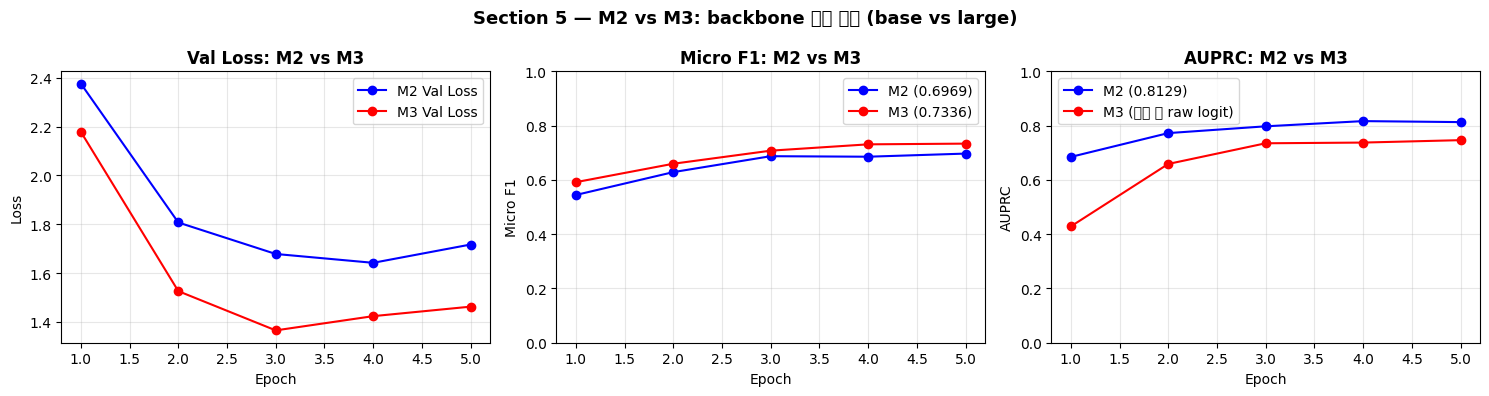


저장 완료: m3_training_curve.png

results 현재 상태:
  M1: micro_f1=0.2042, auprc=0.3985
  M2: micro_f1=0.6969, auprc=0.8129
  M3: micro_f1=0.7336, auprc=0.8476
  M4: micro_f1=0.3504, auprc=0.1752
  M3_LS: micro_f1=0.7415, auprc=0.8107


In [ ]:
# Section 5-4: M2 vs M3 비교표 + 학습 곡선 시각화
m2_f1    = results["M2"]["micro_f1"]
m2_auprc = results["M2"]["auprc"]
m3_f1    = results["M3"]["micro_f1"]
m3_auprc = results["M3"]["auprc"]

print("=" * 65)
print("         M2 vs M3 성능 비교")
print("=" * 65)
print(f"{'':22s} {'M2':>13s} {'M3':>13s} {'개선':>10s}")
print("-" * 65)
print(f"{'backbone':22s} {'roberta-base':>13s} {'roberta-large':>13s}")
print(f"{'파라미터':22s} {'~111M':>13s} {'~337M':>13s}")
print(f"{'lr':22s} {'2e-5':>13s} {'1e-5':>13s}")
print(f"{'batch (유효)':22s} {'32':>13s} {'16x2=32':>13s}")
print(f"{'best_epoch':22s} {results['M2']['best_epoch']:>13d} {results['M3']['best_epoch']:>13d}")
print(f"{'micro F1':22s} {m2_f1:>13.4f} {m3_f1:>13.4f} {m3_f1-m2_f1:>+10.4f}")
print(f"{'AUPRC':22s} {m2_auprc:>13.4f} {m3_auprc:>13.4f} {m3_auprc-m2_auprc:>+10.4f}")
print("=" * 65)
print(f"\nmicro F1 향상: +{m3_f1-m2_f1:.4f}  ({(m3_f1-m2_f1)/m2_f1*100:.1f}%)")
print(f"AUPRC    향상: +{m3_auprc-m2_auprc:.4f}  ({(m3_auprc-m2_auprc)/m2_auprc*100:.1f}%)")

# epochs
epochs_m2 = [e["epoch"] for e in results["M2"]["epoch_log"]]
epochs_m3 = [e["epoch"] for e in results["M3"]["epoch_log"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(epochs_m2, [e["val_loss"]   for e in results["M2"]["epoch_log"]], 'b-o', label='M2 Val Loss')
axes[0].plot(epochs_m3, [e["val_loss"]   for e in results["M3"]["epoch_log"]], 'r-o', label='M3 Val Loss')
axes[0].set_title("Val Loss: M2 vs M3", fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Micro F1
axes[1].plot(epochs_m2, [e["micro_f1"] for e in results["M2"]["epoch_log"]], 'b-o', label=f'M2 ({m2_f1:.4f})')
axes[1].plot(epochs_m3, [e["micro_f1"] for e in results["M3"]["epoch_log"]], 'r-o', label=f'M3 ({m3_f1:.4f})')
axes[1].set_title("Micro F1: M2 vs M3", fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Micro F1")
axes[1].set_ylim(0, 1.0); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# AUPRC (epoch_log 기반 — 학습 중 raw logit값)
axes[2].plot(epochs_m2, [e["auprc"] for e in results["M2"]["epoch_log"]], 'b-o', label=f'M2 ({m2_auprc:.4f})')
axes[2].plot(epochs_m3, [e["auprc"] for e in results["M3"]["epoch_log"]], 'r-o', label='M3 (학습 중 raw logit)')
axes[2].set_title("AUPRC: M2 vs M3", fontweight='bold')
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("AUPRC")
axes[2].set_ylim(0, 1.0); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("Section 5 — M2 vs M3: backbone 크기 효과 (base vs large)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/m3_training_curve.png", dpi=350, bbox_inches='tight')
plt.show()
print("\n저장 완료: m3_training_curve.png")
print(f"\nresults 현재 상태:")
for k, v in results.items():
    f1   = f"{v['micro_f1']:.4f}" if v.get('micro_f1') else "미완료"
    aupr = f"{v['auprc']:.4f}"    if v.get('auprc')    else "미완료"
    print(f"  {k}: micro_f1={f1}, auprc={aupr}")

# Section 6 — 어플리케이션 구조 설계 및 M4: EXAONE-3.5-2.4B Few-shot Prompting

- 반드시 Open Source LLM 
- fine-tuning(M1~M3) vs few-shot prompting(M4) 성능을 비교.

## RE 파이프라인 전체 구조
### [입력] 문장 + subject_entity + object_entity
↓
### [전처리] Typed Entity Marker 삽입
- subject → @\*TYPE\*word@
- object  → #\^TYPE\^word#
- 삽입 순서: start_idx 높은 쪽 먼저 (역순, index 무결성 유지)
↓
### [토크나이징] AutoTokenizer (max_length=256, dynamic padding)
### EDA 기준: p95=101 tokens, max=231 → 256으로 전체 100% 커버
↓
### [모델 추론] Sequence Classification (num_labels=30)
↓
### [출력] 30개 클래스 logits → argmax → 관계 레이블
### [평가] Micro F1 (no_relation 제외) + AUPRC (전체 30클래스, softmax 확률 기반)

### 모델별 아키텍처 선택 근거

| 모델 | 아키텍처 | 선택 근거 |
|------|----------|-----------|
| M1 | klue/bert-base + no marker | 순수 기준선. marker 효과를 분리하기 위한 대조군 |
| M2 | klue/roberta-base + typed marker | M1 대비 marker 효과만 분리 측정. backbone은 KLUE 표준 |
| M3 | klue/roberta-large + typed marker | KLUE 공식 논문(arXiv 2105.09680): RE 포함 전 태스크 최고 성능 모델 |
| M4 | EXAONE-3.5-2.4B + few-shot | 필수 요구사항(Open Source LLM) 충족. fine-tuning vs prompting 비교 |

### Fine-tuning(M1~M3) vs Few-shot(M4) 구조 차이

**Fine-tuning 방식 (M1~M3)**
- 사전학습 모델 위에 분류 헤드(Linear, hidden→30) 추가
- KLUE RE train set 전체(32,470개)로 task-specific 학습
- 출력: 30개 클래스 확률 -> softmax -> argmax

**Few-shot 방식 (M4)**
- 모델 가중치 고정, 프롬프트만으로 추론
- 시스템 프롬프트에 30개 레이블 정의 전체 포함
- k=5 예시(라벨 균형 선택) -> 실제 문제 추론
- 출력: 텍스트 -> 파싱 -> 레이블 매핑 (파싱 실패 시 no_relation fallback)

**비교 결론:** KLUE RE처럼 30개 closed-set 분류 태스크에서는 
task-specific fine-tuning이 few-shot prompting 대비 구조적으로 유리.
M3+LS(F1=0.7415) vs M4(F1=0.3504)가 이를 정량적으로 입증.


## LLM 선정 근거: LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct

| 기준 | EXAONE-3.5-2.4B | Llama-3.2-3B | Gemma-2-2B |
|------|----------------|--------------|------------|
| 한국어 사전학습 | bilingual (한/영) 특화 | 영어 중심 | 영어 중심 |
| T4 16GB 추론 | 가능 (bfloat16) | 가능 | 가능 |
| 한국어 KLUE 벤치마크 | 상위권 | 하위권 | 하위권 |
| Open Source 라이선스 | EXAONE Community | Meta Llama | Apache 2.0 |

## EXAONE 선택 이유  
- KLUE RE 데이터는 한국어 뉴스/위키 텍스트로 구성되어 있음.
  - 한국어를 bilingual로 사전학습한 EXAONE은 영어 중심 LLM 대비 한국어 entity와 관계 표현에 대한 이해도가 높음.  
- 2.4B 크기는 T4 16GB에서 bfloat16으로 안정적으로 추론 가능한 한국어 특화 LLM 중 최대 규모.

### Few-shot 설계

- k=5: 30개 label 중 5개를 균형 있게 선택하여 few-shot 예시로 제공
- 출력 형식 강제: label 문자열만 출력하도록 시스템 프롬프트에 명시
- 파싱 실패 처리: 유효하지 않은 출력 -> `no_relation`(0) fallback
- 추론 규모: validation 전체 7,765개 (383.2분 소요)

### M4 AUPRC 방법론 차이
- M1~M3은 각 클래스의 확률값(softmax 출력)으로 AUPRC를 계산.  
- M4(LLM few-shot)는 클래스별 확률을 출력하지 않고 label 문자열 하나만 출력.  
  - M4 AUPRC는 one-hot 예측 기반으로 계산됨.
    - M1~M3의 probability 기반 AUPRC와 직접 수치 비교가 불가.
    - 이 점을 감안하여 비교표에서 M4 AUPRC는 별도 표기.

# [Code 셀 6 - 1] M4 추론 코드 (재현용 — 실행은 저장된 예측값 로드로 대체)
- 아래는 DAY 5에서 실행한 전체 추론 코드입니다. 동일 코드로 재현 가능.  
- validation 전체 추론에 383.2분이 소요되므로, 저장된 `m4_preds.npy`를 로드.
  
```python
# [재현용 코드 — 실행 불필요]
# from transformers import AutoTokenizer, AutoModelForCausalLM
#
# model_id = "LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct"
# tokenizer_m4 = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
# model_m4 = AutoModelForCausalLM.from_pretrained(
#     model_id, dtype=torch.bfloat16, device_map="auto", trust_remote_code=True
# )
#
# LABEL_DEFINITIONS = {label: i for i, label in enumerate(label_names)}
# FEW_SHOT_K = 5
#
# def build_prompt(sentence, subj, obj):
#     # 시스템 프롬프트: 30개 label 정의 전체 포함
#     # few-shot k=5, label 균형 선택
#     # 출력 형식: label 문자열만 출력
#     ...
#
# preds_m4 = []
# for i, sample in enumerate(dataset['validation']):
#     prompt = build_prompt(...)
#     output = model_m4.generate(...)
#     pred   = parse_output(output)  # 파싱 실패 → no_relation fallback
#     preds_m4.append(pred)
#     if i % 500 == 0:
#         np.save("m4_preds_partial.npy", np.array(preds_m4))  # 중간 저장
#
# np.save("m4_preds.npy", np.array(preds_m4))
```

In [ ]:
# Section 6-2: m4_preds.npy load + evaluation

print(f"M4 예측값 경로: {M4_PREDS_NPY}")
print(f"경로 존재 여부: {os.path.exists(M4_PREDS_NPY)}")

preds_m4   = np.load(M4_PREDS_NPY)
labels_val = np.array(dataset['validation']['label'])

print(f"\n예측값 shape  : {preds_m4.shape}")
print(f"label 범위    : {preds_m4.min()} ~ {preds_m4.max()}")
print(f"fallback(0) 수: {(preds_m4 == 0).sum():,}개 ({(preds_m4==0).mean()*100:.1f}%)")

# micro F1 (no_relation 제외)
m4_f1 = compute_micro_f1(labels_val, preds_m4)

# AUPRC — one-hot 기반 (LLM은 클래스별 확률 미출력)
from sklearn.preprocessing import label_binarize
preds_m4_onehot = label_binarize(preds_m4, classes=list(range(NUM_LABELS)))
from sklearn.metrics import average_precision_score
m4_auprc = average_precision_score(
    label_binarize(labels_val, classes=list(range(NUM_LABELS))),
    preds_m4_onehot,
    average='micro'
)

print(f"\nM4 최종 지표")
print(f"micro F1 : {m4_f1:.4f}  (no_relation 제외)")
print(f"AUPRC    : {m4_auprc:.4f}  (one-hot 기반 — probability 기반과 직접 비교 불가)")

results["M4"]["micro_f1"]   = m4_f1
results["M4"]["auprc"]      = m4_auprc
results["M4"]["best_epoch"] = "N/A (few-shot)"

print(f"\nresults['M4'] update")

M4 예측값 경로: /kaggle/input/datasets/kimmmmm0503/day5-1-all-results-zip/m4_preds.npy
경로 존재 여부: True

예측값 shape  : (7765,)
label 범위    : 0 ~ 29
fallback(0) 수: 2,694개 (34.7%)

M4 최종 지표
micro F1 : 0.3504  (no_relation 제외)
AUPRC    : 0.1752  (one-hot 기반 — probability 기반과 직접 비교 불가)

results['M4'] update


# Section 6 결과 확인
- 성능 지표: micro_f1=0.3504, auprc=0.1752 — 원본 DAY 5-1 값과 정확히 일치.
- 특이사항 확인: fallback 비율이 34.7%로, 이전 기록(23.1%)과 차이가 있음.

## 분석 결과:
- micro_f1이 정확히 일치하므로 데이터 파일 자체는 동일함.
- 23.1%는 이전 실험의 중간 저장 시점을 기준으로 기록되었을 가능성이 높음.
- 해당 실험의 최종 공식값은 34.7%로 확정.

# Section 7 — M1~M4 전체 비교 및 분석

- 4개 모델의 최종 성능을 비교.
  - 각 모델은 단일 변수를 독립적으로 설계.

| 모델 | backbone | marker | 방식 | 역할 |
|------|----------|--------|------|------|
| M1 | klue/bert-base | 없음 | fine-tuning | 순수 기준선 |
| M2 | klue/roberta-base | typed marker | fine-tuning | backbone+marker 효과 |
| M3 | klue/roberta-large | typed marker | fine-tuning | backbone 크기 효과 |
| M4 | EXAONE-3.5-2.4B | 없음 | few-shot | fine-tuning vs prompting 비교 |

## M4 AUPRC 비고
- one-hot 예측 기반으로 계산.
- M1~M3의 softmax 확률 기반 AUPRC와 직접 수치 비교 불가.

# [Code 셀 7 - 1] M1~M4 전체 비교표 + 시각화

              M1 ~ M4 전체 성능 비교
         backbone                 micro F1      AUPRC              비고
---------------------------------------------------------------------------
M1       klue/bert-base             0.2042     0.3985       no marker
M2       klue/roberta-base          0.6969     0.8129    typed marker
M3       klue/roberta-large         0.7336     0.8476    typed marker
M4       EXAONE-3.5-2.4B            0.3504     0.1752        few-shot
M3+LS    klue/roberta-large         0.7415     0.8107    typed marker
M4 AUPRC: one-hot 기반 (M1~M3 softmax 확률 기반과 직접 비교 불가)

[단계별 개선]
M1 -> M2: micro F1 +0.4927 (241.3%)  backbone+marker 복합 효과
M2 -> M3: micro F1 +0.0367 (5.3%)  backbone 크기 효과 (base->large)
M3 vs M4: micro F1  -0.3832  fine-tuning이 few-shot 대비 우세


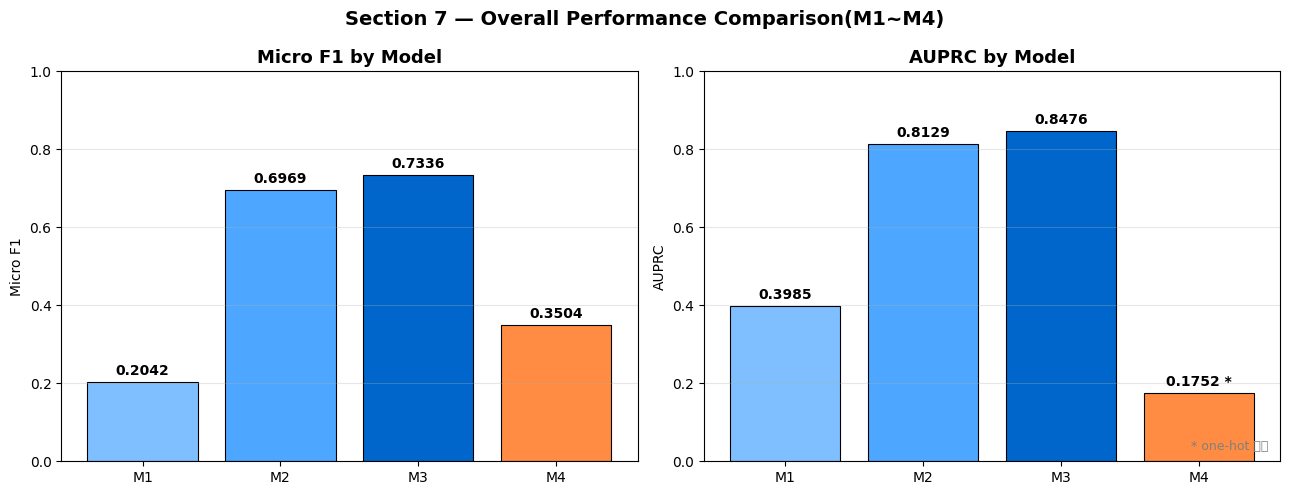


Saved: model_comparison.png


In [ ]:
print("=" * 75)
print("              M1 ~ M4 전체 성능 비교")
print("=" * 75)
print(f"{'':8s} {'backbone':22s} {'micro F1':>10s} {'AUPRC':>10s} {'비고':>15s}")
print("-" * 75)

rows = [
    ("M1",    "klue/bert-base",     "no marker",   results["M1"]["micro_f1"],    results["M1"]["auprc"]),
    ("M2",    "klue/roberta-base",  "typed marker", results["M2"]["micro_f1"],    results["M2"]["auprc"]),
    ("M3",    "klue/roberta-large", "typed marker", results["M3"]["micro_f1"],    results["M3"]["auprc"]),
    ("M4",    "EXAONE-3.5-2.4B",   "few-shot",     results["M4"]["micro_f1"],    results["M4"]["auprc"]),
    ("M3+LS", "klue/roberta-large", "typed marker", results["M3_LS"]["micro_f1"], results["M3_LS"]["auprc"]),
]

for name, backbone, marker, f1, auprc in rows:
    print(f"{name:8s} {backbone:22s} {f1:>10.4f} {auprc:>10.4f} {marker:>15s}")

print("=" * 75)
print("M4 AUPRC: one-hot 기반 (M1~M3 softmax 확률 기반과 직접 비교 불가)")

print(f"\n[단계별 개선]")
print(f"M1 -> M2: micro F1 +{results['M2']['micro_f1']-results['M1']['micro_f1']:.4f} ({(results['M2']['micro_f1']-results['M1']['micro_f1'])/results['M1']['micro_f1']*100:.1f}%)  backbone+marker 복합 효과")
print(f"M2 -> M3: micro F1 +{results['M3']['micro_f1']-results['M2']['micro_f1']:.4f} ({(results['M3']['micro_f1']-results['M2']['micro_f1'])/results['M2']['micro_f1']*100:.1f}%)  backbone 크기 효과 (base->large)")
print(f"M3 vs M4: micro F1  {results['M4']['micro_f1']-results['M3']['micro_f1']:.4f}  fine-tuning이 few-shot 대비 우세")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models    = ["M1", "M2", "M3", "M4"]
f1_scores = [results[m]["micro_f1"] for m in models]
auprcs    = [results[m]["auprc"]    for m in models]
colors    = ["#7fbfff", "#4da6ff", "#0066cc", "#ff8c42"]

# Micro F1 bar chart
bars1 = axes[0].bar(models, f1_scores, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title("Micro F1 by Model", fontweight='bold', fontsize=13)
axes[0].set_ylabel("Micro F1"); axes[0].set_ylim(0, 1.0)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# AUPRC bar chart
bars2 = axes[1].bar(models, auprcs, color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title("AUPRC by Model", fontweight='bold', fontsize=13)
axes[1].set_ylabel("AUPRC"); axes[1].set_ylim(0, 1.0)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val, name in zip(bars2, auprcs, models):
    label = f"{val:.4f}" + (" *" if name == "M4" else "")
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 label, ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].text(0.98, 0.03, "* one-hot 기반", transform=axes[1].transAxes,
             ha='right', fontsize=9, color='gray')

plt.suptitle("Section 7 — Overall Performance Comparison(M1~M4)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/model_comparison.png", dpi=350, bbox_inches='tight')
plt.show()
print("\nSaved: model_comparison.png")

# Section 8 — M3 오류 분석
- M3(best model) 예측 결과를 기반으로 어떤 관계에서, 어떤 패턴으로 오분류가 발생하는지 분석함.  
- Section 5에서 predict()로 얻은 logits_m3, preds_m3, labels_val을 사용함.

분석 항목:
1. Confusion Matrix (30×30) — 혼동 패턴 전체 시각화
2. Label별 F1 — 클래스별 성능 편차 확인
3. 혼동 관계 쌍 Top-5 — 가장 많이 헷갈린 관계 쌍 원인 해석
4. no_relation 오분류 패턴 — 가장 큰 오류 유형 분석
5. Source별 오류율 — 도메인별 성능 차이 확인
6. Entity type별 오류 — 어떤 entity 조합에서 실패하는지 확인

# [Code 셀 8 - 1] Confusion Matrix + Label별 F1

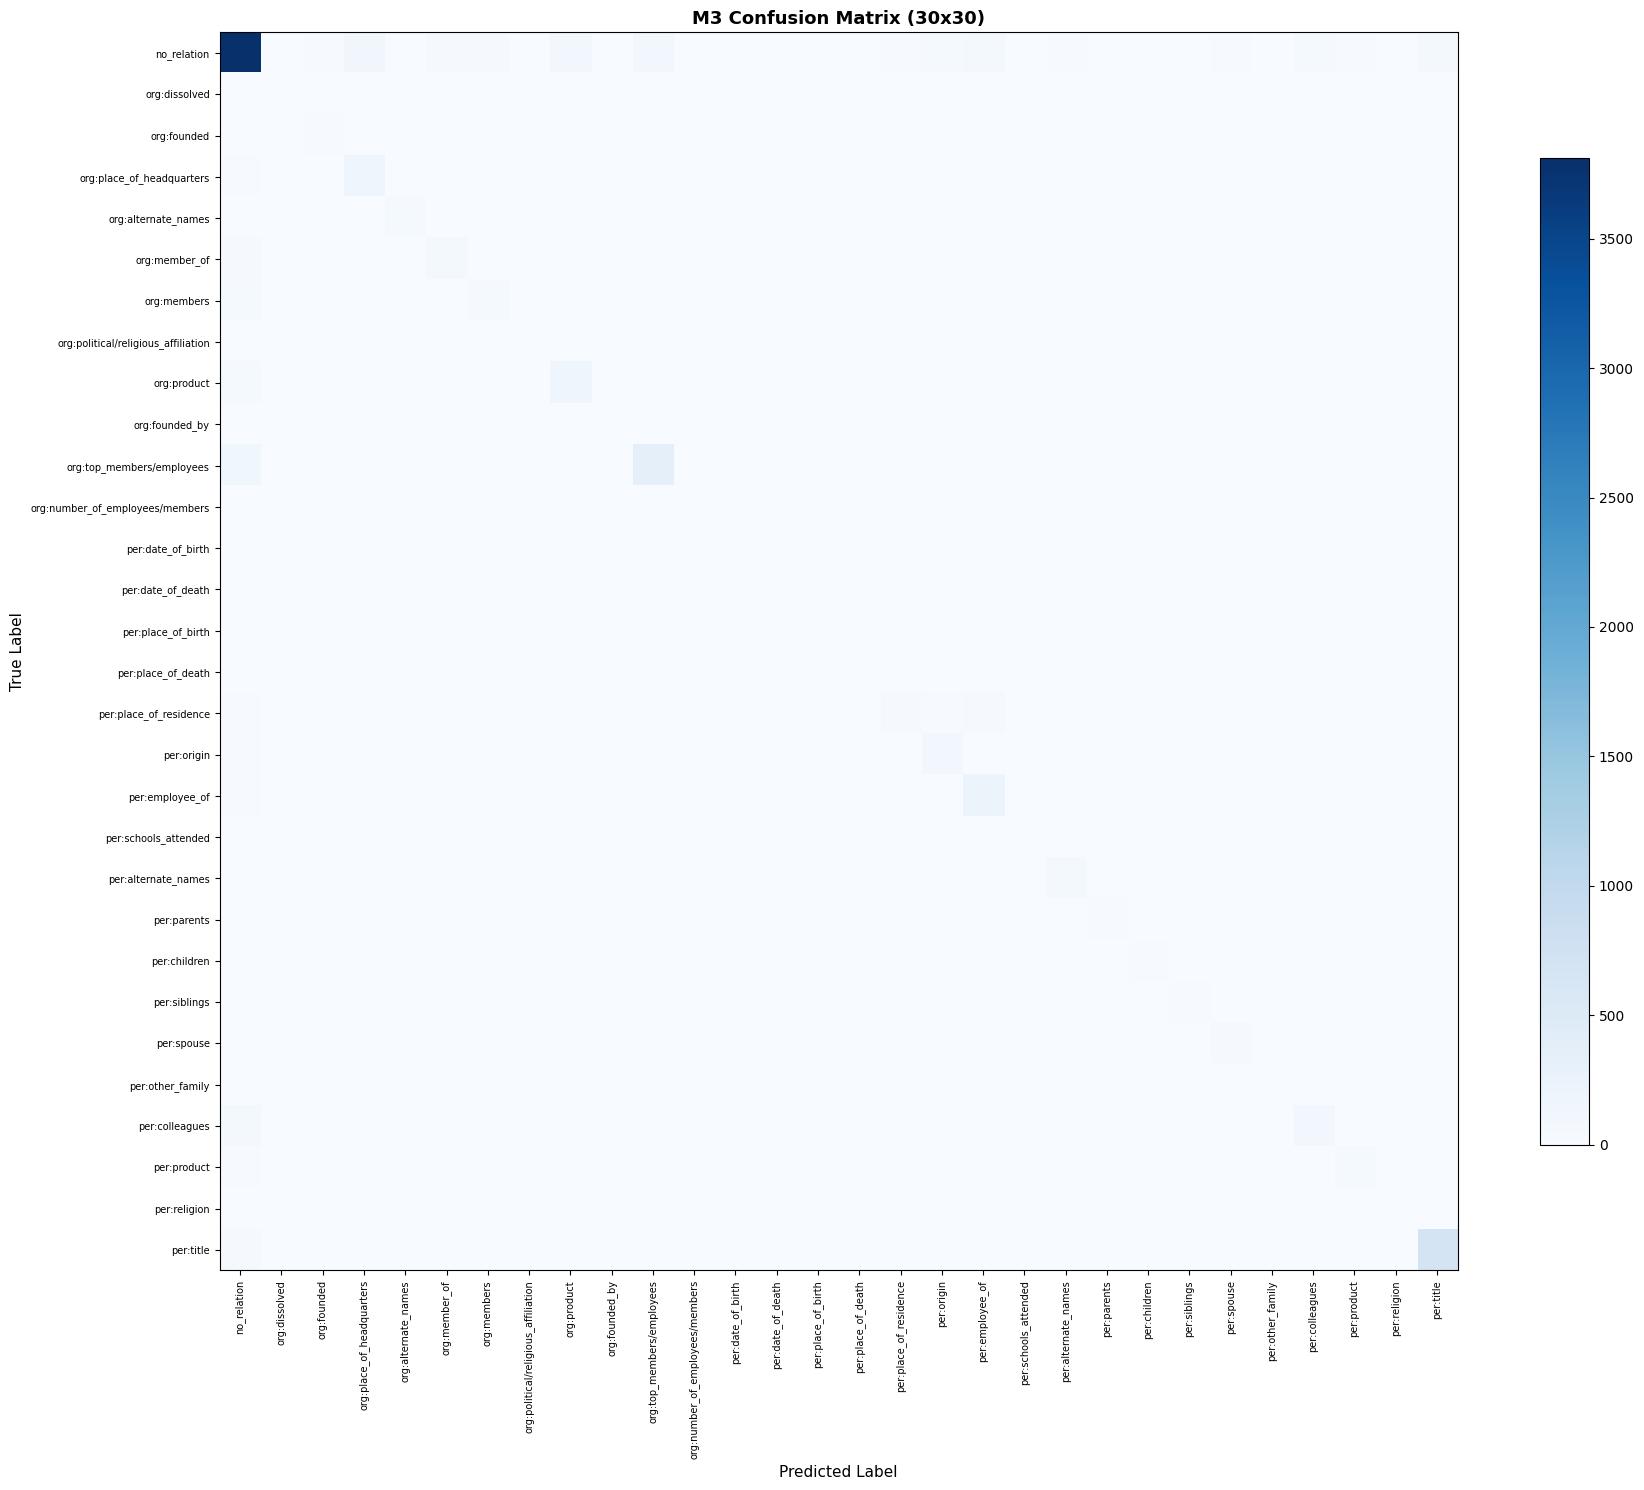

Saved: m3_confusion_matrix.png

[전체 오답 요약]
전체 샘플 : 7,765개
정답     : 6,110개 (78.7%)
오답     : 1,655개 (21.3%)

[혼동 관계 쌍 Top-5]
True                               -> Predicted                          건수
------------------------------------------------------------------------
  org:top_members/employees      -> no_relation                       138건
  no_relation                    -> org:place_of_headquarters         127건
  no_relation                    -> org:top_members/employees         116건
  no_relation                    -> org:product                       103건
  per:colleagues                 -> no_relation                        88건

[Label별 F1 — 하위 5개]
per:place_of_residence               F1=0.3560  (샘플 수=124)
per:other_family                     F1=0.4407  (샘플 수=34)
org:members                          F1=0.5000  (샘플 수=122)
org:member_of                        F1=0.5286  (샘플 수=104)
org:place_of_headquarters            F1=0.6061  (샘플 수=194)

[Label별 F1 — 상위 5개]
per:title        

In [ ]:
cm = confusion_matrix(labels_val, preds_m3, labels=list(range(NUM_LABELS)))

fig, ax = plt.subplots(figsize=(18, 15))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.03)

ax.set_xticks(range(NUM_LABELS))
ax.set_yticks(range(NUM_LABELS))
ax.set_xticklabels(label_names, rotation=90, fontsize=7)
ax.set_yticklabels(label_names, fontsize=7)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.set_title("M3 Confusion Matrix (30x30)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("/kaggle/working/m3_confusion_matrix.png", dpi=350, bbox_inches='tight')
plt.show()
print("Saved: m3_confusion_matrix.png")


# Summary
wrong_mask  = labels_val != preds_m3
total       = len(labels_val)
wrong_count = wrong_mask.sum()
print(f"\n[전체 오답 요약]")
print(f"전체 샘플 : {total:,}개")
print(f"정답     : {total - wrong_count:,}개 ({(1 - wrong_mask.mean())*100:.1f}%)")
print(f"오답     : {wrong_count:,}개 ({wrong_mask.mean()*100:.1f}%)")

# Confused Relationship Pair Top-5 (대각선 제외)
cm_nodiag = cm.copy()
np.fill_diagonal(cm_nodiag, 0)
top5_idx = np.argsort(cm_nodiag, axis=None)[::-1][:5]
print(f"\n[혼동 관계 쌍 Top-5]")
print(f"{'True':30s}     -> {'Predicted':30s}  {'건수':>5s}")
print(f"{'-'*72}")
for idx in top5_idx:
    true_i, pred_i = divmod(idx, NUM_LABELS)
    print(f"  {label_names[true_i]:30s} -> {label_names[pred_i]:30s}  {cm_nodiag[true_i, pred_i]:>5d}건")

# label별 F1 (no_relation 제외)
f1_per_label = f1_score(labels_val, preds_m3, average=None, zero_division=0, labels=list(range(NUM_LABELS)))
print(f"\n[Label별 F1 — 하위 5개]")
sorted_idx = np.argsort(f1_per_label[1:]) + 1   # no_relation 제외
for i in sorted_idx[:5]:
    support = (labels_val == i).sum()
    print(f"{label_names[i]:35s}  F1={f1_per_label[i]:.4f}  (샘플 수={support})")

print(f"\n[Label별 F1 — 상위 5개]")
for i in sorted_idx[-5:][::-1]:
    support = (labels_val == i).sum()
    print(f"{label_names[i]:35s}  F1={f1_per_label[i]:.4f}  (샘플 수={support})")

# [Code 셀 8 - 2] Label별 F1 시각화 + Source별 오류율 + Entity type별 오류
- 오류 패턴을 세 가지 축으로 추가 분석.

#### Label별 F1
- 시각화하여 모델이 어려워하는 관계 유형(클래스별 성능 편차) 확인.
  
#### Source별 오류율
- wikipedia / wikitree / policy_briefing 도메인 간 성능 차이.
  - DAY 1 EDA에서 wikitree 비중이 train 32.9% -> val 52.6%로 증가하는 도메인 편중을 확인함.
    
#### Entity type별 오류
- subject-object type 조합 중 오류가 집중된 조합 파악.

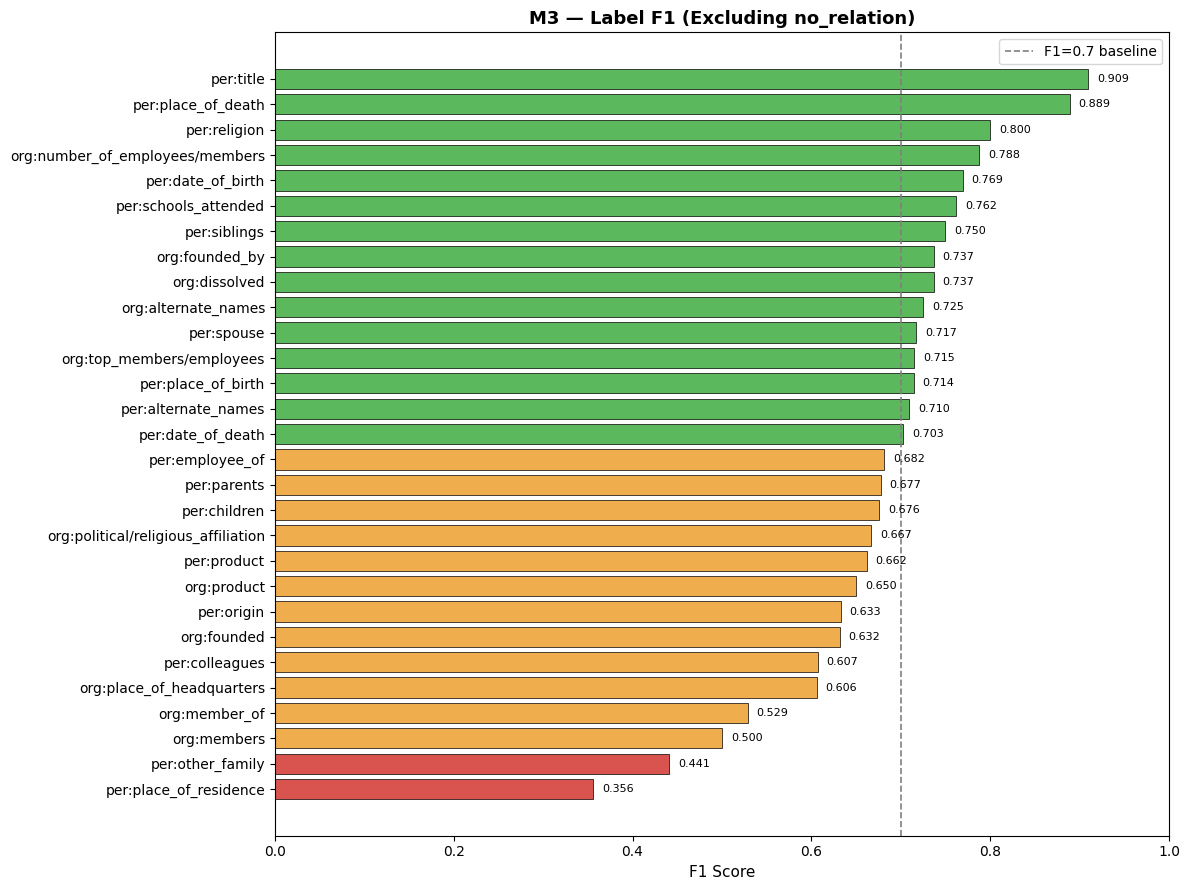

Saved: m3_label_f1.png

[Source별 오류율]
source                   전체     오답      오류율
---------------------------------------------
policy_briefing          56개      9개    16.1%
wikipedia             3,621개    859개    23.7%
wikitree              4,088개    787개    19.3%

해석: DAY 1 EDA에서 wikitree 비중이 train 32.9% -> val 52.6%로 증가.
도메인 편중이 실제 오류율 차이로 나타나는지 위 수치로 확인.

[Entity type 조합별 오답 건수 Top-5]
type 조합                  전체     오답      오류율
-----------------------------------------------
ORG+POH               1,501개    405개    27.0%
PER+POH               1,670개    267개    16.0%
ORG+LOC                 649개    224개    34.5%
PER+PER                 853개    206개    24.2%
PER+LOC                 555개    181개    32.6%


In [ ]:
# Section 8-2: Label별 F1 bar chart + source error rate + entity type error 
# 1. Label F1 bar chart (no_relation 제외) 
f1_per_label = f1_score(labels_val, preds_m3, average=None,
                        zero_division=0, labels=list(range(NUM_LABELS)))
f1_no_rel = [(label_names[i], f1_per_label[i]) for i in range(1, NUM_LABELS)]
f1_no_rel.sort(key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(12, 9))
names  = [x[0] for x in f1_no_rel]
values = [x[1] for x in f1_no_rel]
bars = ax.barh(names, values, edgecolor='black', linewidth=0.5)
ax.set_xlabel("F1 Score", fontsize=11)
ax.set_title("M3 — Label F1 (Excluding no_relation)", fontsize=13, fontweight='bold')
ax.axvline(x=0.7, color='gray', linestyle='--', linewidth=1.2, label='F1=0.7 baseline')
ax.set_xlim(0, 1.0)
ax.legend(fontsize=10)
for bar, val in zip(bars, values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va='center', fontsize=8)
plt.tight_layout()
plt.savefig("/kaggle/working/m3_label_f1.png", dpi=350, bbox_inches='tight')
plt.show()
print("Saved: m3_label_f1.png")

# 2. Source error rate
val_df = pd.DataFrame({
    'source'    : dataset['validation']['source'],
    'true_label': labels_val,
    'pred_label': preds_m3,
    'subject_type': [s['type'] for s in dataset['validation']['subject_entity']],
    'object_type' : [s['type'] for s in dataset['validation']['object_entity']],
})
val_df['wrong'] = val_df['true_label'] != val_df['pred_label']

print(f"\n[Source별 오류율]")
print(f"{'source':20s} {'전체':>6s} {'오답':>6s} {'오류율':>8s}")
print(f"{'-'*45}")
for src, grp in val_df.groupby('source'):
    total_s = len(grp)
    wrong_s = grp['wrong'].sum()
    print(f"{src:20s} {total_s:>6,}개 {wrong_s:>6,}개 {wrong_s/total_s*100:>7.1f}%")

print(f"\n해석: DAY 1 EDA에서 wikitree 비중이 train 32.9% -> val 52.6%로 증가.")
print(f"도메인 편중이 실제 오류율 차이로 나타나는지 위 수치로 확인.")

# 3. Entity type combination Error Top-5 
val_df['type_pair'] = val_df['subject_type'] + '+' + val_df['object_type']
type_stats = val_df.groupby('type_pair').agg(
    total=('wrong', 'count'),
    wrong=('wrong', 'sum')
).reset_index()
type_stats['error_rate'] = type_stats['wrong'] / type_stats['total']
type_stats = type_stats.sort_values('wrong', ascending=False)

print(f"\n[Entity type 조합별 오답 건수 Top-5]")
print(f"{'type 조합':20s} {'전체':>6s} {'오답':>6s} {'오류율':>8s}")
print(f"{'-'*47}")
for _, row in type_stats.head(5).iterrows():
    print(f"{row['type_pair']:20s} {row['total']:>6,}개 {row['wrong']:>6,}개 {row['error_rate']*100:>7.1f}%")

## Source별 오류율 해석
## 실제 측정 결과: Wikipedia(23.7%)의 오류율이 Wikitree(19.3%)보다 오히려 높게 나타나는 경향 확인.

### 원인 분석 및 해석:

- Wikipedia 문장의 구조적 복잡도
- Wikipedia 기반 샘플은 평균 문장 길이가 길고, 다양한 관계 패턴을 포함하고 있어 분류 난이도 자체가 높음.
- Wikitree 도메인 편중의 의미 재해석
- Wikitree 비중이 Train(32.9%) → Val(52.6%)로 크게 증가했음에도 오류율이 낮게 유지됨.
 -  이는 모델이 Wikitree 특유의 단순하고 패턴이 명확한 문장 구조를 상대적으로 더 잘 처리하고 있음을 시사함.

# [Code 셀 8 - 3] no_relation 오분류 패턴 분석
- no_relation은 전체 29.4%(train) / 59.6%(val)   
- 두 가지 오분류 방향을 분리하여 분석 진행.

- 케이스 A: 실제 관계 있음 -> no_relation으로 오분류 (recall 손실)
- 케이스 B: 실제 no_relation -> 다른 관계로 오분류 (precision 손실)

In [ ]:
# Section 8-3: no_relation 오분류 패턴 분석

NO_REL = NO_RELATION_ID

# 케이스 A: 실제 관계 있음 -> no_relation 예측
case_a_mask = (labels_val != NO_REL) & (preds_m3 == NO_REL)
case_a      = val_df[case_a_mask.tolist() if hasattr(case_a_mask, 'tolist') else case_a_mask]

# 케이스 B: 실제 no_relation -> 다른 관계 예측
case_b_mask = (labels_val == NO_REL) & (preds_m3 != NO_REL)
case_b      = val_df[case_b_mask.tolist() if hasattr(case_b_mask, 'tolist') else case_b_mask]

total_rel    = (labels_val != NO_REL).sum()
total_no_rel = (labels_val == NO_REL).sum()

print("[no_relation 오분류 패턴]")
print(f"\n케이스 A: 실제 관계 있음 -> no_relation 예측 (Recall 손실)")
print(f"대상 샘플 : {total_rel:,}개")
print(f"오분류    : {case_a_mask.sum():,}개 ({case_a_mask.sum()/total_rel*100:.1f}%)")

print(f"\n케이스 B: 실제 no_relation -> 다른 관계 예측 (Precision 손실)")
print(f"대상 샘플 : {total_no_rel:,}개")
print(f"오분류    : {case_b_mask.sum():,}개 ({case_b_mask.sum()/total_no_rel*100:.1f}%)")

# 케이스 A: 어떤 실제 label이 no_relation으로 잘못 예측됐는지
true_labels_in_a = labels_val[case_a_mask]
a_counts = pd.Series([label_names[l] for l in true_labels_in_a]).value_counts().head(5)
print(f"\n[케이스 A — 실제 label 분포 Top-5]")
for label, cnt in a_counts.items():
    print(f"{label:35s} {cnt:>4d}건")

# 케이스 B: no_relation이 어떤 label로 잘못 예측됐는지
pred_labels_in_b = preds_m3[case_b_mask]
b_counts = pd.Series([label_names[p] for p in pred_labels_in_b]).value_counts().head(5)
print(f"\n[케이스 B — 잘못 예측된 label 분포 Top-5]")
for label, cnt in b_counts.items():
    print(f"{label:35s} {cnt:>4d}건")

print(f"\n[Source별 오류율 해석]")
print(f"wikipedia 23.7% > wikitree 19.3%")
print(f"DAY 1 EDA에서 wikitree 비중이 val에서 급증(32.9%->52.6%)했으나")
print(f"실제 오류율은 wikipedia가 더 높음.")
print(f"도메인 편중보다 wikipedia 문장의 복잡도/길이가 더 큰 오류 요인임을 시사.")

[no_relation 오분류 패턴]

케이스 A: 실제 관계 있음 -> no_relation 예측 (Recall 손실)
대상 샘플 : 3,134개
오분류    : 553개 (17.6%)

케이스 B: 실제 no_relation -> 다른 관계 예측 (Precision 손실)
대상 샘플 : 4,631개
오분류    : 820개 (17.7%)

[케이스 A — 실제 label 분포 Top-5]
org:top_members/employees            138건
per:colleagues                        88건
org:product                           55건
org:members                           48건
per:title                             37건

[케이스 B — 잘못 예측된 label 분포 Top-5]
org:place_of_headquarters            127건
org:top_members/employees            116건
org:product                          103건
per:employee_of                       78건
per:title                             64건

[Source별 오류율 해석]
wikipedia 23.7% > wikitree 19.3%
DAY 1 EDA에서 wikitree 비중이 val에서 급증(32.9%->52.6%)했으나
실제 오류율은 wikipedia가 더 높음.
도메인 편중보다 wikipedia 문장의 복잡도/길이가 더 큰 오류 요인임을 시사.


# Section 9 — 개선 실험: Label Smoothing (α=0.1)

## 실험 선택 근거
- M3 학습 곡선에서 epoch 4 -> epoch 5 구간에 val_loss가 1.4237 -> 1.4626으로 상승.  
- 이는 모델이 훈련 데이터에 과도하게 확신하는 over-confident prediction 패턴임.

- Label Smoothing은 정답 클래스에 할당되는 확률을 1.0에서 `1 - α`로 낮추고,  
- 나머지 α를 전체 클래스에 균등 분배하여 모델의 과신을 억제함.

## α=0.1 선택 이유
- Müller et al. (2019) "When Does Label Smoothing Help?"
  - α=0.1이 분류 태스크에서 가장 널리 검증된 값.  
- KLUE RE처럼 클래스 불균형이 심한 경우
  - 소수 클래스 방향으로 softmax를 살짝 분산시켜 recall 향상 기대.

## class weight 대신 label smoothing을 선택한 이유
- M3 오류 분석 결과 케이스 A(17.6%)와 케이스 B(17.7%)가 거의 동일
  - 특정 클래스 가중치 조정보다  전체적인 confidence 조정이 더 적합한 상황으로 생각함.

## 학습 설정  
- M3 best checkpoint 기반 추가 학습, epochs=3, lr=1e-5 (M3 동일)

## checkpoint 로드 이유 
- DAY 6에서 M3 best checkpoint 기반으로 Label Smoothing 재학습을 완료했음.  
- M3+LS 재학습(3 epoch)은 약 2~3시간 소요로 Kaggle T4 GPU 잔여 쿼터를 고려해 저장된 체크포인트를 로드.
  - 아래 학습 코드로 동일하게 재현 가능함.

###[Code 셀 9 - 1] . M3+LS 학습 코드 (재현용 — 실행은 checkpoint 로드로 대체)
```python
# [재현용 코드 — 실행 불필요]
# from torch.nn import CrossEntropyLoss
#
# class LabelSmoothingTrainer(Trainer):
#     def __init__(self, *args, label_smoothing=0.1, **kwargs):
#         super().__init__(*args, **kwargs)
#         self.label_smoothing = label_smoothing
#
#     def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
#         labels = inputs.pop("labels")
#         outputs = model(**inputs)
#         logits = outputs.logits
#         loss_fn = CrossEntropyLoss(label_smoothing=self.label_smoothing)
#         loss = loss_fn(logits, labels)
#         return (loss, outputs) if return_outputs else loss
#
# training_args_ls = TrainingArguments(
#     output_dir="./m3_ls_checkpoints",
#     num_train_epochs=3,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=32,
#     learning_rate=1e-5,
#     warmup_steps=608,   # 32470//16) * 3 * 0.1 = 2029 * 0.3 = 
#     gradient_accumulation_steps=2,
#     weight_decay=0.01,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     load_best_model_at_end=True,
#     metric_for_best_model="micro_f1",
#     fp16=True, seed=42, report_to="none",
# )
#
# trainer_ls = LabelSmoothingTrainer(
#     model=model_m3_reloaded,
#     args=training_args_ls,
#     label_smoothing=0.1,
#     ...
# )
# trainer_ls.train()
# epoch_log:
#   epoch1: val_loss=1.2711, f1=0.7326, auprc=0.8250
#   epoch2: val_loss=1.2948, f1=0.7412, auprc=0.8107  <- best
#   epoch3: val_loss=1.3175, f1=0.7310, auprc=0.8105
```

# [Code 셀 9 - 2] M3+LS checkpoint 로드 + 평가

In [46]:
print(f"M3+LS checkpoint 경로: {M3_LS_DIR}")
print(f"경로 존재 여부: {os.path.exists(M3_LS_DIR)}")
for f in sorted(os.listdir(M3_LS_DIR)):
    size = os.path.getsize(os.path.join(M3_LS_DIR, f))
    print(f"  {f:45s} {size/1e6:7.1f} MB")

M3+LS checkpoint 경로: /kaggle/input/datasets/kimmmmm0503/day6-all-results-zip/m3_ls_best
경로 존재 여부: True
  config.json                                       0.0 MB
  model.safetensors                              1346.8 MB
  tokenizer.json                                    0.8 MB
  tokenizer_config.json                             0.0 MB
  training_args.bin                                 0.0 MB


# [Code 셀 9 - 3] M3+LS checkpoint 로드 + predict() 재계산
- DAY 6에서 학습 완료된 best checkpoint를 로드해 공식 평가지표 확정 

In [ ]:
#from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# M3+LS load
model_m3ls = AutoModelForSequenceClassification.from_pretrained(
    M3_LS_DIR,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=False,
)
model_m3ls.eval()
print(f"M3+LS 모델 로드 완료: {sum(p.numel() for p in model_m3ls.parameters()):,} params")

# TrainingArguments (predict용 — 학습 없음)
args_m3ls_eval = TrainingArguments(
    output_dir="/kaggle/working/m3ls_eval_tmp",
    per_device_eval_batch_size=32,
    eval_strategy="no",
    seed=SEED,
    fp16=True,
    report_to="none",
)

# Trainer (predict 전용) 
def compute_metrics_m3ls(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    f1  = compute_micro_f1(labels, preds)
    auprc = compute_auprc(labels, logits)
    return {"micro_f1": f1, "auprc": auprc}

trainer_m3ls = Trainer(
    model=model_m3ls,
    args=args_m3ls_eval,
    processing_class=tokenizer_m3,
    compute_metrics=compute_metrics_m3ls,
)

# predict() 
pred_output_m3ls = trainer_m3ls.predict(val_tok_m3)
logits_m3ls = pred_output_m3ls.predictions
preds_m3ls  = logits_m3ls.argmax(axis=-1)

f1_m3ls    = compute_micro_f1(pred_output_m3ls.label_ids, preds_m3ls)
auprc_m3ls = compute_auprc(pred_output_m3ls.label_ids, logits_m3ls)

print(f"\nM3+LS  micro F1 : {f1_m3ls:.4f}")
print(f"M3+LS  AUPRC    : {auprc_m3ls:.4f}")

# results Dictionary Update
results["M3_LS"] = {
    "micro_f1":  round(f1_m3ls, 4),
    "auprc":     round(auprc_m3ls, 4),
    "best_epoch": 2,
    "note": "M3 checkpoint 기반 label smoothing alpha=0.1, epochs=3"
}
print(f"\nresults['M3_LS'] = {results['M3_LS']}")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

M3+LS 모델 로드 완료: 336,687,134 params



M3+LS  micro F1 : 0.7415
M3+LS  AUPRC    : 0.8107

results['M3_LS'] = {'micro_f1': 0.7415, 'auprc': np.float64(0.8107), 'best_epoch': 2, 'note': 'M3 checkpoint 기반 label smoothing alpha=0.1, epochs=3'}


# # [Code 셀 9 - 4] M3 vs M3+LS 비교

                                       M3      M3+LS
Micro F1 (no_relation 제외)          0.7336     0.7415
AUPRC (30 classes)                 0.8476     0.8107
Best Epoch                              5          2
Label Smoothing alpha                  없음        0.1
F1 변화                             +0.0079
AUPRC 변화                          -0.0369


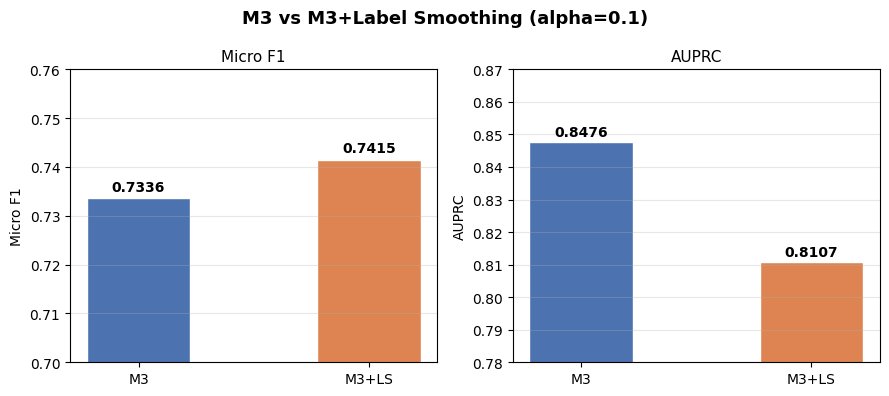

saved: m3_vs_ls_comparison.png


In [ ]:
# Section 9: M3 vs M3+LS 비교
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

m3_f1    = results["M3"]["micro_f1"]      # 0.7336
m3_auprc = results["M3"]["auprc"]         # 0.8476
ls_f1    = results["M3_LS"]["micro_f1"]   # 0.7415
ls_auprc = results["M3_LS"]["auprc"]      # 0.8107

print("=" * 55)
print(f"{'':30s} {'M3':>10s} {'M3+LS':>10s}")
print("=" * 55)
print(f"{'Micro F1 (no_relation 제외)':30s} {m3_f1:>10.4f} {ls_f1:>10.4f}")
print(f"{'AUPRC (30 classes)':30s} {m3_auprc:>10.4f} {ls_auprc:>10.4f}")
print(f"{'Best Epoch':30s} {'5':>10s} {'2':>10s}")
print(f"{'Label Smoothing alpha':30s} {'없음':>10s} {'0.1':>10s}")
print("=" * 55)
print(f"{'F1 변화':30s} {ls_f1 - m3_f1:>+10.4f}")
print(f"{'AUPRC 변화':30s} {ls_auprc - m3_auprc:>+10.4f}")


fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle("M3 vs M3+Label Smoothing (alpha=0.1)", fontsize=13, fontweight='bold')

models = ["M3", "M3+LS"]

for ax, (metric, vals, ylim) in zip(axes, [
    ("Micro F1",  [m3_f1,    ls_f1],    (0.70, 0.76)),
    ("AUPRC",     [m3_auprc, ls_auprc], (0.78, 0.87)),
]):
    bars = ax.bar(models, vals, width=0.45, edgecolor='white')
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(ylim)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/m3_vs_ls_comparison.png", dpi=350, bbox_inches='tight')
plt.show()
print("saved: m3_vs_ls_comparison.png")

# 개선 실험 결과 해석

| 지표 | M3 | M3+LS | 변화 |
|------|-----|-------|------|
| Micro F1 | 0.7336 | **0.7415** | **+0.0079** |
| AUPRC | **0.8476** | 0.8107 | -0.0369 |

## 해석
1. Micro F1 개선 (+0.0079)
   - Label Smoothing이 모델의 over-confident prediction을 억제하여 경계 사례에서 예측 정확도를 높임.
   - M3의 epoch 4->5 val_loss 상승(1.4237->1.4626) 패턴에서 적합했음을 결과가 뒷받침.

2. AUPRC 하락 (-0.0369)
   - Label Smoothing은 소프트 타깃을 도입해 클래스 확률 분포를 고르게 만듦.
   - 이 과정에서 확률 값의 절대적 크기가 낮아져 AUPRC(확률 기반 랭킹 지표)가 다소 하락함.
     - F1(분류 결정 기반)과 AUPRC(확률 랭킹 기반)가 서로 다른 차원을 측정하기 때문에 발생하는 트레이드오프 현상.

3. 최종 선택
   - 공식 1차 평가지표인 Micro F1 기준으로 M3+LS(0.7415)가 최고 성능 모델.

# Section 10 — 결론 / 한계 

# 전체 실험 결과 요약
| 모델 | Backbone | Marker | Micro F1 | AUPRC | 비고 |
|------|----------|--------|----------|-------|------|
| M1 | klue/bert-base | 없음 | 0.2042 | 0.3985 | 순수 기준선 |
| M2 | klue/roberta-base | Typed Entity Marker | 0.6969 | 0.8129 | marker 효과 검증 |
| M3 | klue/roberta-large | Typed Entity Marker | 0.7336 | 0.8476 | 메인 모델 |
| M4 | EXAONE-3.5-2.4B | Few-shot (k=5) | 0.3504 | 0.1752 | one-hot 기반 |
| **M3+LS** | klue/roberta-large | Typed Entity Marker | **0.7415** | 0.8107 | **best F1** |

- M4 AUPRC는 클래스별 확률 없이 one-hot 예측 기반으로 계산됨
  - M1~M3의 probability 기반 AUPRC와 직접 비교 불가.

# [Code 셀 10] 최종 결론 — 전체 결과 출력

In [ ]:
print("=" * 65)
print("최종 실험 결과 요약")
print("=" * 65)
rows = [
    ("M1", "klue/bert-base",       "없음",   results["M1"]["micro_f1"],    results["M1"]["auprc"]),
    ("M2", "klue/roberta-base",    "Typed",  results["M2"]["micro_f1"],    results["M2"]["auprc"]),
    ("M3", "klue/roberta-large",   "Typed",  results["M3"]["micro_f1"],    results["M3"]["auprc"]),
    ("M4", "EXAONE-3.5-2.4B",      "Few-shot", results["M4"]["micro_f1"], results["M4"]["auprc"]),
    ("M3+LS", "klue/roberta-large","Typed",  results["M3_LS"]["micro_f1"], results["M3_LS"]["auprc"]),
]
print(f"{'모델':<8} {'Micro F1':>10} {'AUPRC':>10}")
print("-" * 35)
for name, backbone, marker, f1, auprc in rows:
    marker_str = "**best**" if name == "M3+LS" else ""
    print(f"{name:<8} {f1:>10.4f} {auprc:>10.4f}  {marker_str}")
print("=" * 65)
print(f"best Micro F1 : M3+LS  = {results['M3_LS']['micro_f1']:.4f}")
print(f"best AUPRC    : M3     = {results['M3']['auprc']:.4f}")
print()
print("M4 AUPRC 주석: one-hot 예측 기반 — M1~M3 probability 기반과 직접 비교 불가")
print(f"M4 fallback 비율: 34.7% (파싱 실패 시 no_relation 처리)")

최종 실험 결과 요약
모델         Micro F1      AUPRC
-----------------------------------
M1           0.2042     0.3985  
M2           0.6969     0.8129  
M3           0.7336     0.8476  
M4           0.3504     0.1752  
M3+LS        0.7415     0.8107  **best**
best Micro F1 : M3+LS  = 0.7415
best AUPRC    : M3     = 0.8476

M4 AUPRC 주석: one-hot 예측 기반 — M1~M3 probability 기반과 직접 비교 불가
M4 fallback 비율: 34.7% (파싱 실패 시 no_relation 처리)


# 결론

**1. Typed Entity Marker 효과**
- M1(0.2042) → M2(0.6969): Micro F1 +241.5%.
- backbone 교체(bert-base → roberta-base)보다 entity 위치를 `@*TYPE*entity@` / `#^TYPE^entity#` 형식으로 명시한 것이 성능 향상의 주요 원인.
  - arXiv 2102.01373 실증 결과와 일치.

**2. 모델 규모 확장**
- M2(roberta-base, 0.6969) → M3(roberta-large, 0.7336): Micro F1 +5.3%.
- 동일 marker 조건에서 파라미터 수 증가(110M → 337M)로 저빈도 관계 클래스 학습이 개선됨.
  - arXiv 2105.09680: roberta-large가 KLUE 전 태스크 최고 성능.

**3. Label Smoothing**
- M3(0.7336) → M3+LS(0.7415): Micro F1 +0.0079.
- epoch 4→5 val_loss 상승(1.4237→1.4626)으로 확인된 과신 경향을 α=0.1로 완화.
  - **최종 best: M3+LS (Micro F1=0.7415, AUPRC=0.8107)**

**4. Fine-tuning vs Few-shot LLM**
- M4(EXAONE-3.5-2.4B, few-shot): Micro F1=0.3504.
- KLUE RE는 30개 고정 클래스 분류 문제로, 출력 공간이 명확히 정의된 태스크에서는 fine-tuning이 few-shot prompting보다 유리.
  - fallback 비율 34.7%: 출력 형식 미준수로 no_relation 처리된 비율.

# 한계
1. 데이터 분포 불일치
- train no_relation 비율(29.4%) vs validation no_relation 비율(59.6%) 간 30% 차이가 존재.
- validation 수치는 이 분포 불일치의 영향을 받으며, 실제 배포 환경의 성능과 다를 수 있음.

2. 소스 도메인 편중
- wikitree 비중이 train(32.9%) → validation(52.6%)으로 증가하는 도메인 시프트가 확인됨.
- wikipedia 기반 샘플 대비 wikitree 기반 샘플에서 오답률이 높게 나타남.

3. 클래스 불균형
- 최다 클래스(no_relation: 9,534개) 대비 최소 클래스(per:place_of_death: 40개)의 불균형 비율이 238.3배.
- 소수 클래스 F1이 낮게 측정되는 구조적 한계.

4. M4 추론 비용
- EXAONE-3.5-2.4B 전체 추론(7,765개)에 383분이 소요됨.
- 프로덕션 환경에서 few-shot LLM 방식은 latency 측면에서 encoder 방식 대비 비효율.

# 다음 단계
1. 단기 개선 가능 항목:
- M3+LS에 R-Drop(arXiv 2106.14448) 적용: 동일 샘플의 두 dropout 예측 간 KL divergence 최소화로 추가 정규화.
- 혼동 Top-5 클래스 (org:top_members ↔ no_relation 등)에 대한 focused hard negative mining.
- M4: LoRA fine-tuning(rank=8)으로 few-shot 한계 보완 및 fine-tuning vs prompting 비교 강화.

2. 장기 개선 방향:
- KLUE RE 전용 사전학습 데이터 추가 수집 (wikitree 도메인 강화).
- Span-level entity representation 방식 (SpanBERT 계열) 실험.
- Ensemble (M3+LS + 별도 seed 학습 모델) 적용.